In [23]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from collections import defaultdict

from constants import RANDOM_STATE

plt.style.use('bmh')

In [47]:
WORD2SUBTOKEN = {
    'gptj': {
        'den': 'Ġden',
        'die': 'Ġdie',
        'das': 'Ġd'
    },
    'mgpt': {
        'den': 'Ġden',
        'die': 'Ġdie',
        'das': 'Ġdas'
    }
}

In [45]:
def word_starts_with_subtoken(row, layer, pred, tag_name, model_tag):
    word = row[tag_name]
    if word in WORD2SUBTOKEN[model_tag].keys():
#         print(row[f'layer_{layer}_pred_{pred}'])
#         print(WORD2SUBTOKEN[model_tag][word])
        return row[f'layer_{layer}_pred_{pred}'] == WORD2SUBTOKEN[model_tag][word]
    return word.startswith(row[f'layer_{layer}_pred_{pred}'].replace('Ġ', ''))

In [62]:
# m 
dataset_gptj_habe.apply(word_starts_with_subtoken, args=[18, 0, 'noun_eng', 'gptj'], axis=1)

0      False
1       True
2      False
3      False
4      False
       ...  
555    False
556    False
557    False
558     True
559    False
Length: 560, dtype: bool

In [10]:
dataset_gptj_habe.layer_27_pred_0

0      Ġden
1      Ġden
2        Ġd
3      Ġdie
4      Ġdie
       ... 
555      te
556    Ġden
557      Ġd
558      Ġd
559      te
Name: layer_27_pred_0, Length: 560, dtype: object

In [24]:
def dataset_indices(dataset):
    """Set up indices that can then be used as slices for specific subsets
    """
    dataset_by_index = defaultdict()
    dataset_by_index['subj_i'] = dataset[dataset.sentence_e.str.startswith('I')].index
    dataset_by_index['subj_h'] = dataset[dataset.sentence_e.str.startswith('He')].index
    dataset_by_index['subj_m'] = dataset[dataset.sentence_e.str.startswith('The man')].index
    dataset_by_index['subj_w'] = dataset[dataset.sentence_e.str.startswith('The woman')].index

    dataset_by_index['apple'] = dataset[dataset.noun_eng == 'apple'].index
    dataset_by_index['milk'] = dataset[dataset.noun_eng == 'milk'].index
    dataset_by_index['ball'] = dataset[dataset.noun_eng == 'ball'].index
    dataset_by_index['dress'] = dataset[dataset.noun_eng == 'dress'].index
    dataset_by_index['game'] = dataset[dataset.noun_eng == 'game'].index
    dataset_by_index['president'] = dataset[dataset.noun_eng == 'president'].index
    dataset_by_index['man'] = dataset[dataset.noun_eng == 'man'].index
    dataset_by_index['woman'] = dataset[dataset.noun_eng == 'woman'].index
    return dataset_by_index

In [25]:
def layer_arrays(dataset, num_layers):
    """Set up arrays that are easier to plot
    """
    layer_arrays = defaultdict(lambda: np.zeros((len(dataset), num_layers)))

    for l in range(num_layers):
        layer_arrays[f'top3_perf_eng'][:, l] = dataset[f'top3_{l}_perf_eng'].to_numpy(dtype=np.int64)
        layer_arrays[f'top3_past_eng'][:, l] = dataset[f'top3_{l}_past_eng'].to_numpy(dtype=np.int64)
        layer_arrays[f'top3_perf_ger'][:, l] = dataset[f'top3_{l}_perf_ger'].to_numpy(dtype=np.int64)
        layer_arrays[f'top3_noun_eng'][:, l] = dataset[f'top3_{l}_noun_eng'].to_numpy(dtype=np.int64)
        layer_arrays[f'top3_noun_ger'][:, l] = dataset[f'top3_{l}_noun_ger'].to_numpy(dtype=np.int64)
        layer_arrays[f'top1_art_ger'][:, l] = (dataset[f'layer_{l}_pred_0'].str.replace('Ġ', '') == dataset['art_ger'].str[:]).to_numpy(dtype=np.int64)
        layer_arrays[f'top3_art_ger'][:, l] = dataset[f'top3_{l}_art_ger'].to_numpy(dtype=np.int64)
    layer_arrays['top3_verb_eng'] = ((layer_arrays[f'top3_perf_eng'] == 1) | (layer_arrays[f'top3_past_eng'] == 1)).astype(np.int64)
    
    return layer_arrays

In [26]:
def plot_by_layer(l_arrays, num_layers, top_tag, title="", ylabel="", savefig=None, dpi=300, xlines=[]):
    """Layer-wise plot
    """
    plt.plot(l_arrays[top_tag].mean(axis=0))
    plt.ylim([0, 1])
    plt.xticks(np.arange(num_layers), rotation=90)
    
    for line in xlines:
        plt.axvline(x=line, color='gray', linestyle=":")
    
    plt.title(title)
    plt.xlabel("Layer")
    plt.ylabel(ylabel)
    
    if savefig:
        plt.savefig(savefig, dpi=dpi)
    
    plt.show()

In [27]:
from constants import RANDOM_STATE

In [28]:
NUM_LAYERS = 28
SAMPLE_SIZE = 70
SENTENCE_CSV_PATH = "data/dataset_gptj_haben.csv"

# loading the sentence dataset
dataset_gptj_habe = pd.read_csv(SENTENCE_CSV_PATH, index_col=0)
dataset_gptj_habe['coll_freq_per_million'] = (dataset_gptj_habe['coll_freq'] / dataset_gptj_habe['obj_freq']) * 10**6
dataset_gptj_habe = dataset_gptj_habe.groupby('noun_ger').sample(n=SAMPLE_SIZE, random_state=RANDOM_STATE) # equalizing the dataset
dataset_gptj_habe.reset_index(drop=True, inplace=True)

gptj_habe_d_indices = dataset_indices(dataset_gptj_habe)
gptj_habe_l_arrays = layer_arrays(dataset_gptj_habe, NUM_LAYERS)


In [29]:
# m
(dataset_gptj_habe[f'layer_26_pred_0'].str.replace('Ġ', '') == dataset_gptj_habe['art_ger'].str).mean()

0.0

In [30]:
dataset_gptj_habe[f'layer_26_pred_0'].str.replace('Ġ', '') == dataset_gptj_habe['art_ger'].str[:]

0       True
1      False
2       True
3       True
4       True
       ...  
555    False
556    False
557    False
558    False
559    False
Length: 560, dtype: bool

In [31]:
dataset_gptj_habe['art_ger'].str[:]

0      den
1      den
2      den
3      den
4      den
      ... 
555    das
556    das
557    das
558    das
559    das
Name: art_ger, Length: 560, dtype: object

Creating matrices of layer prediction indicators, so that it would be easier to plot them:

Apart from the indicators we do have, it would be sensible to have one for predicting a past form of the English verb as well:

## Top-3

### Different word predictions by layer

#### English noun

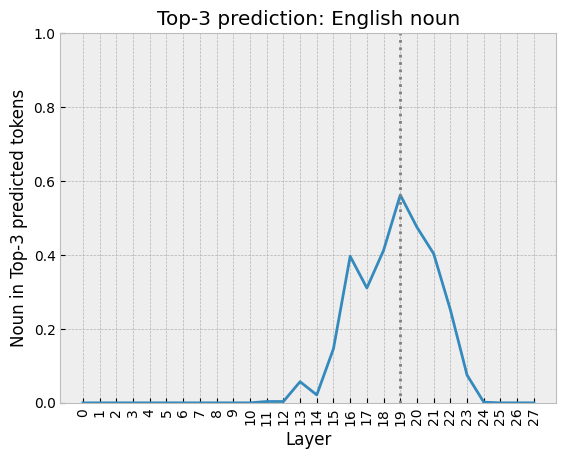

In [44]:
plot_by_layer(
    gptj_habe_l_arrays,
    NUM_LAYERS,
    "top3_noun_eng",
    title="Top-3 prediction: English noun",
    ylabel="Noun in Top-3 predicted tokens",
    xlines=[19]
)

##### by object

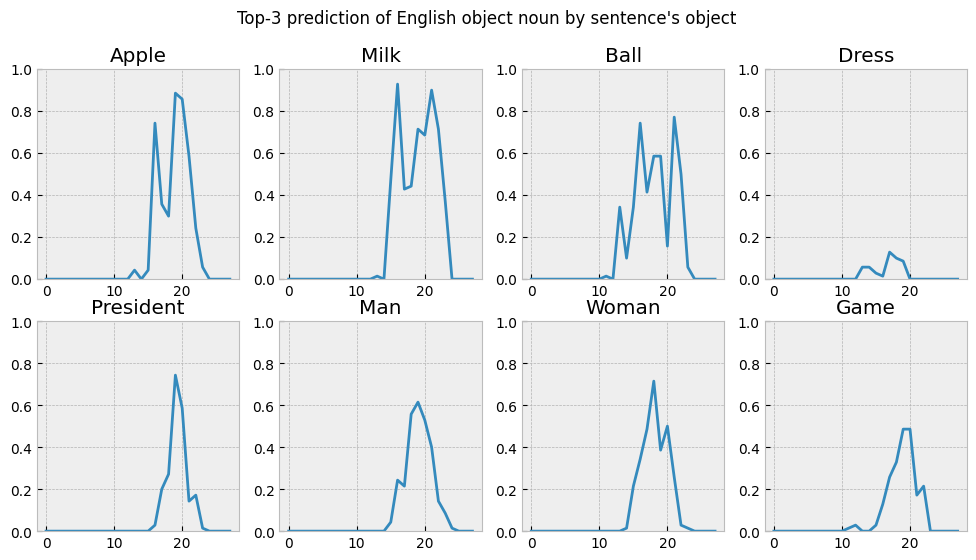

In [33]:
figure = plt.figure(figsize=(12,6))
figure.suptitle("Top-3 prediction of English object noun by sentence's object")

axis = figure.subplots(2, 4)

axis[0, 0].plot(gptj_habe_l_arrays['top3_noun_eng'][gptj_habe_d_indices['apple']].mean(axis=0))
axis[0, 0].set_ylim([0,1])
axis[0, 0].set_title("Apple")

axis[0, 1].plot(gptj_habe_l_arrays['top3_noun_eng'][gptj_habe_d_indices['milk']].mean(axis=0))
axis[0, 1].set_ylim([0,1])
axis[0, 1].set_title("Milk")

axis[0, 2].plot(gptj_habe_l_arrays['top3_noun_eng'][gptj_habe_d_indices['ball']].mean(axis=0))
axis[0, 2].set_ylim([0,1])
axis[0, 2].set_title("Ball")

axis[0, 3].plot(gptj_habe_l_arrays['top3_noun_eng'][gptj_habe_d_indices['dress']].mean(axis=0))
axis[0, 3].set_ylim([0,1])
axis[0, 3].set_title("Dress")

axis[1, 0].plot(gptj_habe_l_arrays['top3_noun_eng'][gptj_habe_d_indices['president']].mean(axis=0))
axis[1, 0].set_ylim([0,1])
axis[1, 0].set_title("President")

axis[1, 1].plot(gptj_habe_l_arrays['top3_noun_eng'][gptj_habe_d_indices['man']].mean(axis=0))
axis[1, 1].set_ylim([0,1])
axis[1, 1].set_title("Man")

axis[1, 2].plot(gptj_habe_l_arrays['top3_noun_eng'][gptj_habe_d_indices['woman']].mean(axis=0))
axis[1, 2].set_ylim([0,1])
axis[1, 2].set_title("Woman")

axis[1, 3].plot(gptj_habe_l_arrays['top3_noun_eng'][gptj_habe_d_indices['game']].mean(axis=0))
axis[1, 3].set_ylim([0,1])
axis[1, 3].set_title("Game")

# plt.savefig("visualisations/figures/noun_eng_top3_by_obj.png", dpi=300)
plt.show()

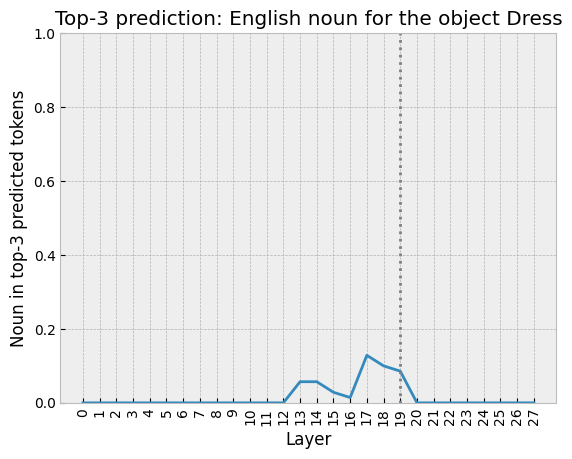

In [45]:
# more detailed plot of dress
plt.plot(gptj_habe_l_arrays['top3_noun_eng'][gptj_habe_d_indices["dress"]].mean(axis=0))
plt.ylim([0, 1])
plt.xticks(np.arange(28), rotation=90)
plt.axvline(x=19, color='gray', linestyle=":")
plt.title("Top-3 prediction: English noun for the object Dress")
plt.xlabel("Layer")
plt.ylabel("Noun in top-3 predicted tokens")
plt.show()

##### Dress

In [23]:
dataset_gptj_habe[dataset_gptj_habe.noun_eng == 'dress'].layer_19_pred_0.value_counts()

Ġdie           27
Ġthe           18
Ġchoice         8
te              3
Ġfound          2
Ġdiscovered     2
Ġmit            2
Ġchanged        2
Ġordered        1
Ġpresented      1
Ġseen           1
Ġgift           1
Ġopen           1
Ġmissed         1
Name: layer_19_pred_0, dtype: int64

In [24]:
dataset_gptj_habe[dataset_gptj_habe.noun_eng == 'game'].layer_19_pred_0.value_counts()

Ġgame             23
Ġdie               5
Ġstart             4
Ġthe               3
Ġunderstanding     3
Ġrecommended       3
Ġimproved          2
Ġwatched           2
Ġled               2
Ġcontrol           2
Ġmissed            2
Ġenjoyed           2
Ġprepared          2
Ġinterrupted       1
Ġpresented         1
Ġoffer             1
Ġmanaged           1
Ġpublished         1
te                 1
Ġmit               1
Ġexpected          1
Ġdownloaded        1
Ġwin               1
Ġcreated           1
Ġbegin             1
Ġgames             1
Ġplayed            1
Ġbroadcast         1
Name: layer_19_pred_0, dtype: int64

##### by subject

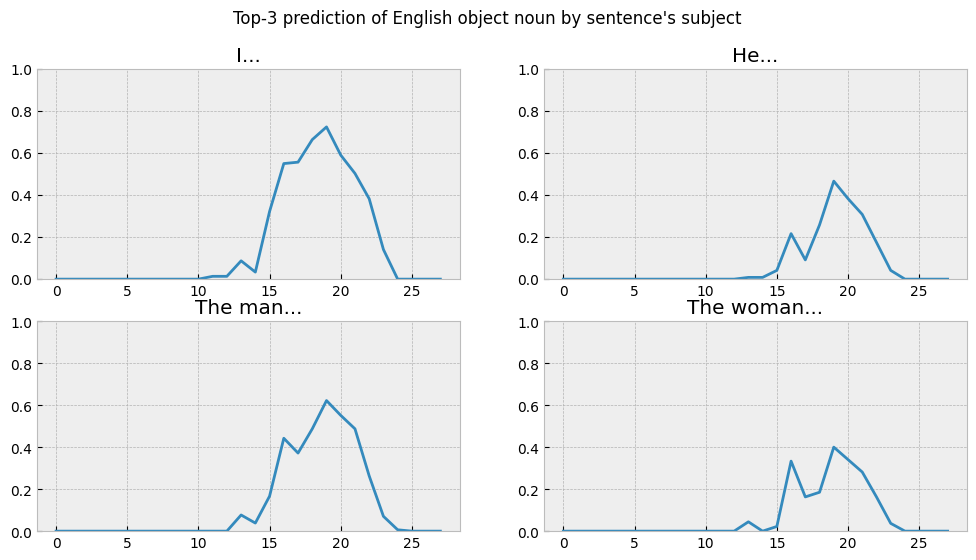

In [46]:
figure = plt.figure(figsize=(12,6))
figure.suptitle("Top-3 prediction of English object noun by sentence's subject")

axis = figure.subplots(2, 2)

axis[0, 0].plot(gptj_habe_l_arrays['top3_noun_eng'][gptj_habe_d_indices["subj_i"]].mean(axis=0))
axis[0, 0].set_ylim([0,1])
axis[0, 0].set_title("I...")

axis[0, 1].plot(gptj_habe_l_arrays['top3_noun_eng'][gptj_habe_d_indices["subj_h"]].mean(axis=0))
axis[0, 1].set_ylim([0,1])
axis[0, 1].set_title("He...")

axis[1, 0].plot(gptj_habe_l_arrays['top3_noun_eng'][gptj_habe_d_indices["subj_m"]].mean(axis=0))
axis[1, 0].set_ylim([0,1])
axis[1, 0].set_title("The man...")

axis[1, 1].plot(gptj_habe_l_arrays['top3_noun_eng'][gptj_habe_d_indices["subj_w"]].mean(axis=0))
axis[1, 1].set_ylim([0,1])
axis[1, 1].set_title("The woman...")

plt.show()

#### English verb

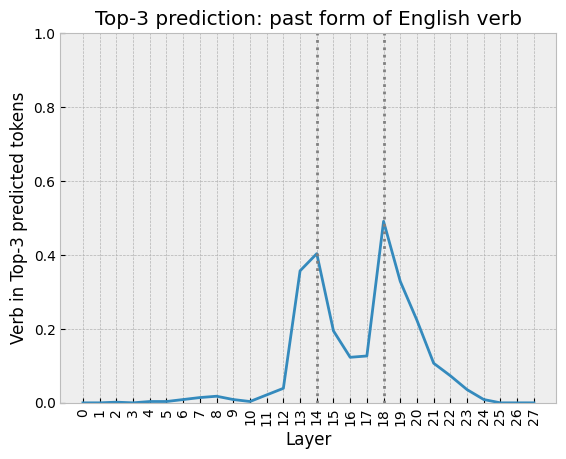

In [47]:
plot_by_layer(
    gptj_habe_l_arrays,
    NUM_LAYERS,
    "top3_verb_eng",
    title="Top-3 prediction: past form of English verb",
    ylabel="Verb in Top-3 predicted tokens",
    xlines=[14, 18]
)

##### by object

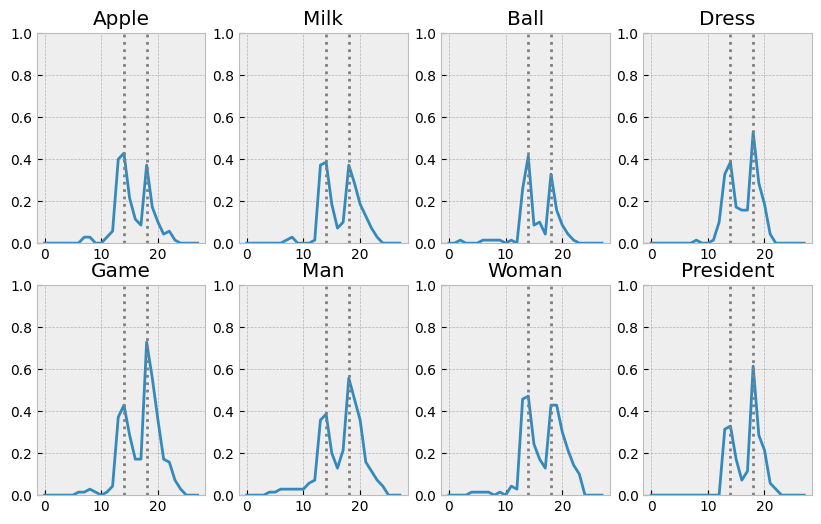

In [48]:
figure = plt.figure(figsize=(10,6))
axis = figure.subplots(2, 4)

axis[0, 0].plot(gptj_habe_l_arrays['top3_verb_eng'][gptj_habe_d_indices["apple"]].mean(axis=0))
axis[0, 0].set_ylim([0,1])
axis[0, 0].axvline(x=14, color='gray', linestyle=":")
axis[0, 0].axvline(x=18, color='gray', linestyle=":")
axis[0, 0].set_title("Apple")

axis[0, 1].plot(gptj_habe_l_arrays['top3_verb_eng'][gptj_habe_d_indices["milk"]].mean(axis=0))
axis[0, 1].set_ylim([0,1])
axis[0, 1].axvline(x=14, color='gray', linestyle=":")
axis[0, 1].axvline(x=18, color='gray', linestyle=":")
axis[0, 1].set_title("Milk")

axis[0, 2].plot(gptj_habe_l_arrays['top3_verb_eng'][gptj_habe_d_indices["ball"]].mean(axis=0))
axis[0, 2].set_ylim([0,1])
axis[0, 2].axvline(x=14, color='gray', linestyle=":")
axis[0, 2].axvline(x=18, color='gray', linestyle=":")
axis[0, 2].set_title("Ball")

axis[0, 3].plot(gptj_habe_l_arrays['top3_verb_eng'][gptj_habe_d_indices["dress"]].mean(axis=0))
axis[0, 3].set_ylim([0,1])
axis[0, 3].axvline(x=14, color='gray', linestyle=":")
axis[0, 3].axvline(x=18, color='gray', linestyle=":")
axis[0, 3].set_title("Dress")

axis[1, 0].plot(gptj_habe_l_arrays['top3_verb_eng'][gptj_habe_d_indices["game"]].mean(axis=0))
axis[1, 0].set_ylim([0,1])
axis[1, 0].axvline(x=14, color='gray', linestyle=":")
axis[1, 0].axvline(x=18, color='gray', linestyle=":")
axis[1, 0].set_title("Game")

axis[1, 1].plot(gptj_habe_l_arrays['top3_verb_eng'][gptj_habe_d_indices["man"]].mean(axis=0))
axis[1, 1].set_ylim([0,1])
axis[1, 1].axvline(x=14, color='gray', linestyle=":")
axis[1, 1].axvline(x=18, color='gray', linestyle=":")
axis[1, 1].set_title("Man")

axis[1, 2].plot(gptj_habe_l_arrays['top3_verb_eng'][gptj_habe_d_indices["woman"]].mean(axis=0))
axis[1, 2].set_ylim([0,1])
axis[1, 2].axvline(x=14, color='gray', linestyle=":")
axis[1, 2].axvline(x=18, color='gray', linestyle=":")
axis[1, 2].set_title("Woman")

axis[1, 3].plot(gptj_habe_l_arrays['top3_verb_eng'][gptj_habe_d_indices["president"]].mean(axis=0))
axis[1, 3].set_ylim([0,1])
axis[1, 3].axvline(x=14, color='gray', linestyle=":")
axis[1, 3].axvline(x=18, color='gray', linestyle=":")
axis[1, 3].set_title("President")

# plt.savefig('results/figures/verb_eng_top3_by_obj.png', dpi=300)
plt.show()

##### by subject

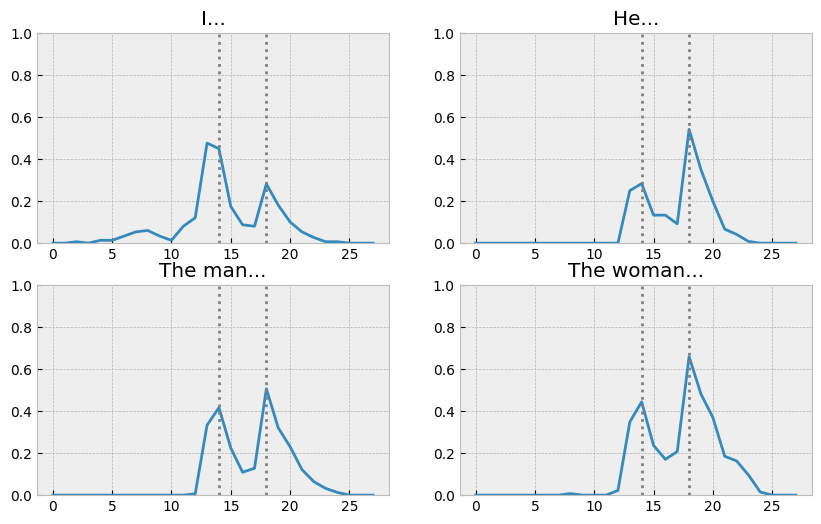

In [49]:
figure = plt.figure(figsize=(10,6))
axis = figure.subplots(2, 2)

axis[0, 0].plot(gptj_habe_l_arrays['top3_verb_eng'][gptj_habe_d_indices["subj_i"]].mean(axis=0))
axis[0, 0].set_ylim([0,1])
axis[0, 0].axvline(x=14, color='gray', linestyle=":")
axis[0, 0].axvline(x=18, color='gray', linestyle=":")
axis[0, 0].set_title("I...")

axis[0, 1].plot(gptj_habe_l_arrays['top3_verb_eng'][gptj_habe_d_indices["subj_h"]].mean(axis=0))
axis[0, 1].set_ylim([0,1])
axis[0, 1].axvline(x=14, color='gray', linestyle=":")
axis[0, 1].axvline(x=18, color='gray', linestyle=":")
axis[0, 1].set_title("He...")

axis[1, 0].plot(gptj_habe_l_arrays['top3_verb_eng'][gptj_habe_d_indices["subj_m"]].mean(axis=0))
axis[1, 0].set_ylim([0,1])
axis[1, 0].axvline(x=14, color='gray', linestyle=":")
axis[1, 0].axvline(x=18, color='gray', linestyle=":")
axis[1, 0].set_title("The man...")

axis[1, 1].plot(gptj_habe_l_arrays['top3_verb_eng'][gptj_habe_d_indices["subj_w"]].mean(axis=0))
axis[1, 1].set_ylim([0,1])
axis[1, 1].axvline(x=14, color='gray', linestyle=":")
axis[1, 1].axvline(x=18, color='gray', linestyle=":")
axis[1, 1].set_title("The woman...")

plt.show()

##### Qualitative analysis

In [50]:
dataset_gptj_habe[(gptj_habe_l_arrays['top3_verb_eng'][:, 18] == 1)].groupby('noun_ger').mean()['coll_freq_per_million']


noun_ger
Apfel         657.587512
Ball         1881.902883
Frau          585.678849
Kleid        1608.326652
Mann          431.756370
Milch        1349.912517
Präsident     259.006906
Spiel         936.838612
Name: coll_freq_per_million, dtype: float64

In [73]:
print(
pd.concat(
    [dataset[(layer_arrays['verb_eng_top3'][:, 18] == 1)].groupby('noun_ger').mean()['coll_freq_per_million'],
    dataset[(layer_arrays['verb_eng_top3'][:, 18] == 0)].groupby('noun_ger').mean()['coll_freq_per_million']],
    axis=1
).to_latex()
)

\begin{tabular}{lrr}
\toprule
{} &  coll\_freq\_per\_million &  coll\_freq\_per\_million \\
noun\_ger  &                        &                        \\
\midrule
Apfel     &             638.644661 &            1361.053222 \\
Ball      &            1375.153776 &            2941.909227 \\
Frau      &             611.551452 &             420.426411 \\
Kleid     &            1572.023120 &            1497.976093 \\
Mann      &             489.307410 &             447.044499 \\
Milch     &             899.307150 &            1811.428465 \\
Präsident &             268.419250 &             229.406650 \\
Spiel     &             949.706879 &            1642.634089 \\
\bottomrule
\end{tabular}



In [34]:
print(
    dataset[(layer_arrays['verb_eng_top3'][:, 18] == 1)].groupby('noun_ger').mean()['coll_freq_per_million'].to_latex()
)

\begin{tabular}{lr}
\toprule
{} &  coll\_freq\_per\_million \\
noun\_ger  &                        \\
\midrule
Apfel     &             564.620820 \\
Ball      &            1310.006548 \\
Frau      &             499.284966 \\
Kleid     &            1216.023490 \\
Mann      &             636.451325 \\
Milch     &             986.773279 \\
Präsident &             191.739853 \\
Spiel     &            1534.692311 \\
\bottomrule
\end{tabular}



In [64]:
dataset[(layer_arrays['verb_eng_top3'][:, 18] == 1)].mean()['coll_freq_per_million']

/Users/fixed/Desktop/saar/word_order_logitlens/envs/word-order/lib/python3.7/site-packages/ipykernel_launcher.py:1: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  """Entry point for launching an IPython kernel.


834.1530484472901

In [83]:
dataset[(layer_arrays['verb_eng_top3'][:, 18] == 1)].perf_eng.unique()

array(['added', 'painted', 'shown', 'recognised', 'cut', 'shared',
       'replaced', 'seen', 'discovered', 'offered', 'received', 'enjoyed',
       'chosen', 'found', 'washed', 'named', 'stopped', 'controlled',
       'rolled', 'provided', 'touched', 'intercepted', 'reached', 'asked',
       'sent', 'visited', 'taken', 'watched', 'married', 'raped', 'known',
       'heard', 'killed', 'bought', 'brought', 'portrayed', 'held',
       'ordered', 'presented', 'opened', 'tailored', 'changed',
       'required', 'missed', 'saved', 'called', 'noticed', 'judged',
       'labelled', 'expected', 'reminded', 'arrested', 'sold', 'refused',
       'drawn', 'prepared', 'produced', 'delivered', 'tolerated',
       'needed', 'milked', 'transformed', 'recommended', 'appointed',
       'removed', 'protected', 'empowered', 'invited', 'met',
       'represented', 'elected', 'convinced', 'demonstrated',
       'designated', 'defended', 'honoured', 'insulted', 'transferred',
       'instructed', 'requested

In [27]:
dataset[(layer_arrays['verb_eng_top3'][:, 18] == 1)].groupby('noun_eng').layer_18_noun_eng_top3.mean()

noun_eng
apple        0.222222
ball         0.304348
dress        0.000000
game         0.224490
man          0.323529
milk         0.269231
president    0.078947
woman        0.531250
Name: layer_18_noun_eng_top3, dtype: float64

In [29]:
dataset[(layer_arrays['verb_eng_top3'][:, 18] == 1)].groupby('noun_eng').layer_18_noun_eng_top3.mean().mean()

0.24425217420550926

In [28]:
dataset[(layer_arrays['verb_eng_top3'][:, 18] == 0)].groupby('noun_ger').mean()['coll_freq_per_million']

noun_ger
Apfel        1289.031923
Ball         2683.921280
Frau          489.371776
Kleid        1774.847129
Mann          523.025918
Milch        2462.921369
Präsident     232.658204
Spiel        1083.017114
Name: coll_freq_per_million, dtype: float64

In [29]:
dataset[(layer_arrays['verb_eng_top3'][:, 18] == 0)].mean()['coll_freq_per_million']

/Users/fixed/Desktop/saar/word_order_logitlens/envs/word-order/lib/python3.7/site-packages/ipykernel_launcher.py:1: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  """Entry point for launching an IPython kernel.


1424.6078013394083

In [82]:
dataset[(layer_arrays['verb_eng_top3'][:, 18] == 0)].perf_eng.unique()

array(['grated', 'discovered', 'held', 'turned', 'replaced', 'halved',
       'consumed', 'diced', 'pressed', 'cored', 'stolen', 'recognised',
       'eaten', 'painted', 'gifted', 'brought', 'rubbed', 'washed',
       'peeled', 'quartered', 'taken', 'found', 'conquered', 'reached',
       'stopped', 'received', 'intercepted', 'touched', 'kicked',
       'secured', 'won', 'parried', 'rolled', 'provided', 'raped',
       'killed', 'bought', 'seen', 'left', 'saved', 'portrayed', 'freed',
       'hit', 'known', 'named', 'murdered', 'lost', 'got', 'worn', 'cut',
       'ordered', 'thrown', 'shown', 'manufactured', 'packed', 'sewn',
       'wrapped', 'tailored', 'set', 'kept', 'opened', 'required',
       'visited', 'kissed', 'seduced', 'met', 'shot', 'seated', 'hurt',
       'labelled', 'mixed', 'used', 'drunk', 'whisked', 'fed',
       'transformed', 'spilled', 'given', 'poured', 'sucked', 'squirted',
       'frothed', 'dispensed', 'helped', 'drawn', 'utilised', 'tilted',
       'stirred',

In [30]:
dataset[(layer_arrays['verb_eng_top3'][:, 18] == 0)].groupby('noun_eng').layer_18_noun_eng_top3.mean()

noun_eng
apple        0.511628
ball         0.744681
dress        0.171429
game         0.761905
man          0.916667
milk         0.750000
president    0.656250
woman        0.973684
Name: layer_18_noun_eng_top3, dtype: float64

In [31]:
dataset[(layer_arrays['verb_eng_top3'][:, 18] == 0)].groupby('noun_eng').layer_18_noun_eng_top3.mean().mean()

0.6857803710708612

In [31]:
dataset[dataset_index_woman][(layer_arrays['verb_eng_top3'][:, 18] == 0)].layer_18_preds

AttributeError: 'Int64Index' object has no attribute 'index'

#### English Past Pariciple vs. Past

For those sentences, where the predicate is a verb with two different forms, such as *ate*/*eaten* or *took*/*taken*:

In [51]:
different_verbforms = dataset_gptj_habe[dataset_gptj_habe.perf_eng != dataset_gptj_habe.past_eng]
different_verbforms.tail()

,sentence_f,sentence_e,coll_freq,logdice,obj_freq,perf_ger,perf_eng,past_eng,art_ger,noun_ger,...,top3_19_art_ger,top3_20_art_ger,top3_21_art_ger,top3_22_art_ger,top3_23_art_ger,top3_24_art_ger,top3_25_art_ger,top3_26_art_ger,top3_27_art_ger,coll_freq_per_million
514,Die Frau hat das Spiel begonnen,The woman began the game,10304,7.48,5774929,begonnen,begun,began,das,Spiel,...,False,False,False,False,False,False,True,True,True,1784.264361
525,Er hat das Spiel genommen,He took the game,7006,5.10,5774929,genommen,taken,took,das,Spiel,...,False,False,False,False,False,True,True,True,True,1213.175088
528,Die Frau hat das Spiel genommen,The woman took the game,7006,5.10,5774929,genommen,taken,took,das,Spiel,...,False,False,False,False,False,True,True,True,True,1213.175088
553,Ich habe das Spiel gesehen,I saw the game,20910,7.00,5774929,gesehen,seen,saw,das,Spiel,...,False,False,False,False,False,True,True,True,True,3620.823737
558,Der Mann hat das Spiel geholt,The man took the game,2533,5.40,5774929,geholt,taken,took,das,Spiel,...,False,False,False,False,False,True,True,True,True,438.620111


What are the predictions of the past participle verb forms compared past simple?

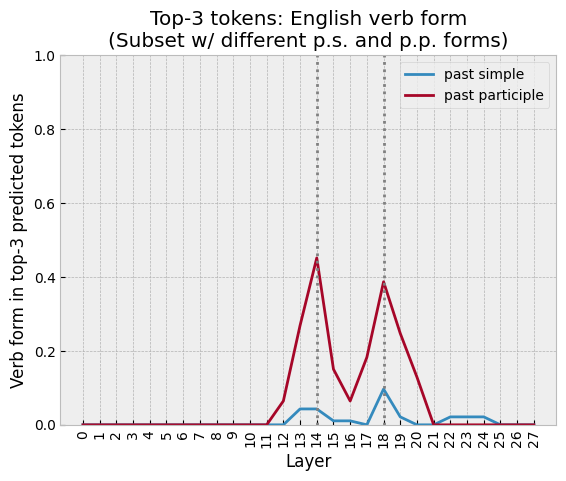

In [55]:
past_forms = gptj_habe_l_arrays['top3_past_eng'][different_verbforms.index].mean(axis=0)
perf_forms = gptj_habe_l_arrays['top3_perf_eng'][different_verbforms.index].mean(axis=0)

plt.plot(past_forms, label="past simple")
plt.plot(perf_forms, label="past participle")
plt.ylim([0, 1])
plt.xticks(np.arange(28), rotation=90)
plt.axvline(x=14, color='gray', linestyle=":")
plt.axvline(x=18, color='gray', linestyle=":")
plt.title("Top-3 tokens: English verb form\n(Subset w/ different p.s. and p.p. forms)")
plt.xlabel("Layer")
plt.ylabel("Verb form in top-3 predicted tokens")
plt.legend()
# plt.savefig("results/figures/past_vs_perf_eng.png", dpi=300)
plt.show()

#### English Noun vs. English Verb

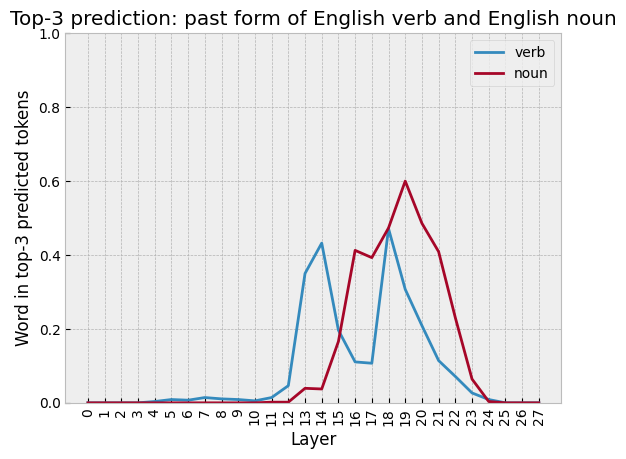

In [34]:
plt.plot(layer_arrays['verb_eng_top3'].mean(axis=0), label="verb")
plt.plot(layer_arrays['noun_eng_top3'].mean(axis=0), label="noun")
plt.ylim([0, 1])
plt.xticks(np.arange(28), rotation=90)
plt.title("Top-3 prediction: past form of English verb and English noun")
plt.xlabel("Layer")
plt.ylabel("Word in top-3 predicted tokens")
plt.legend()

plt.savefig('results/figures/verb_vs_noun_eng.png', dpi=300)
plt.show()

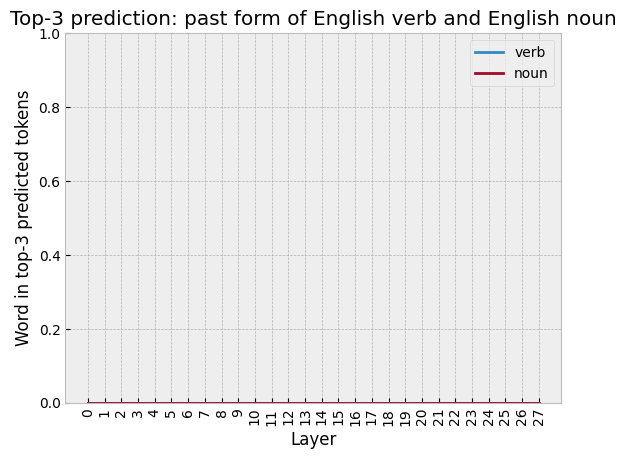

In [39]:
plt.plot(gptj_habe_l_arrays['verb_eng_top3'].mean(axis=0), label="verb")
plt.plot(gptj_habe_l_arrays['noun_eng_top3'].mean(axis=0), label="noun")
plt.ylim([0, 1])
plt.xticks(np.arange(28), rotation=90)
plt.title("Top-3 prediction: past form of English verb and English noun")
plt.xlabel("Layer")
plt.ylabel("Word in top-3 predicted tokens")
plt.legend()

# plt.savefig('results/figures/verb_vs_noun_eng.png', dpi=300)
plt.show()

# mGPT

In [7]:
SENTENCE_CSV_PATH = "data/dataset_mgpt_haben.csv"
NUM_LAYERS = 24
SAMPLE_SIZE = 70

# loading the sentence dataset
dataset_mgpt_habe = pd.read_csv(SENTENCE_CSV_PATH, index_col=0)
dataset_mgpt_habe['coll_freq_per_million'] = (dataset_mgpt_habe['coll_freq'] / dataset_mgpt_habe['obj_freq']) * 10**6
dataset_mgpt_habe = dataset_mgpt_habe.groupby('noun_ger').sample(n=SAMPLE_SIZE, random_state=RANDOM_STATE) # equalizing the dataset
dataset_mgpt_habe.reset_index(drop=True, inplace=True)

mgpt_habe_d_indices = dataset_indices(dataset_mgpt_habe)
mgpt_habe_l_arrays = layer_arrays(dataset_mgpt_habe, NUM_LAYERS)


In [159]:
# m
dataset_mgpt_habe[
    ['art_ger',
     'layer_20_pred_0',
     'layer_20_pred_2',
     'layer_20_pred_0_correctart_ger',
     'layer_20_pred_2_correctart_ger',
     'layer_20_pred_0_wrongart_ger',
     'layer_20_pred_2_wrongart_ger']
]

,art_ger,layer_20_pred_0,layer_20_pred_2,layer_20_pred_0_correctart_ger,layer_20_pred_2_correctart_ger,layer_20_pred_0_wrongart_ger,layer_20_pred_2_wrongart_ger
0,den,Ġdie,Ġden,False,True,True,False
1,den,Ġdie,Ġdas,False,False,True,True
2,den,Ġdie,Ġfestgestellt,False,False,True,False
3,den,Ġdie,Ġdas,False,False,True,True
4,den,Ġdie,Ġdas,False,False,True,True
...,...,...,...,...,...,...,...
555,das,Ġangeboten,Ġdas,False,True,False,False
556,das,Ġgespielt,Ġden,False,False,False,True
557,das,Ġbesser,Ġmich,False,False,False,False
558,das,Ġgespielt,Ġdie,False,False,False,True


In [147]:
for layer_i in range(NUM_LAYERS):
    for subtoken in ['Ġden', 'Ġdie', 'Ġdas']:
        for k in range(3):
            dataset_mgpt_habe[f'layer_{layer_i}_pred_{k}_correctart_ger'] = dataset_mgpt_habe[f'layer_{layer_i}_pred_{k}'].str.replace('Ġ', '') == dataset_mgpt_habe['art_ger']
            dataset_mgpt_habe[f'layer_{layer_i}_pred_{k}_wrongart_ger'] = (
                (dataset_mgpt_habe[f'layer_{layer_i}_pred_{k}'].str.replace('Ġ', '') != dataset_mgpt_habe['art_ger']) & dataset_mgpt_habe[f'layer_{layer_i}_pred_{k}'].isin(['Ġden', 'Ġdie', 'Ġdas'])
            )
            

/Users/fixed/Desktop/saar/word-order-thesis/envs/word-order/lib/python3.7/site-packages/ipykernel_launcher.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead.  To get a de-fragmented frame, use `newframe = frame.copy()`
  after removing the cwd from sys.path.
/Users/fixed/Desktop/saar/word-order-thesis/envs/word-order/lib/python3.7/site-packages/ipykernel_launcher.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead.  To get a de-fragmented frame, use `newframe = frame.copy()`
  


In [148]:
for layer_i in range(NUM_LAYERS):
    dataset_mgpt_habe[f'top3_{layer_i}_wrongart_ger'] = (
        dataset_mgpt_habe[[
            f'layer_{layer_i}_pred_0_wrongart_ger',
            f'layer_{layer_i}_pred_1_wrongart_ger',
            f'layer_{layer_i}_pred_2_wrongart_ger'
        ]]
    ).any(axis='columns')
    

### Nouns

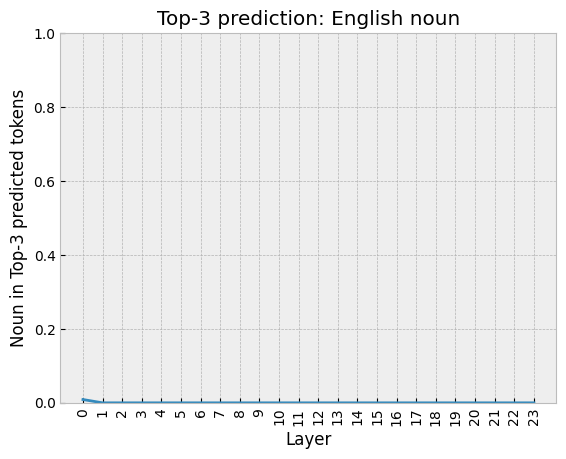

In [8]:
plot_by_layer(
    mgpt_habe_l_arrays,
    NUM_LAYERS,
    "top3_noun_eng",
    title="Top-3 prediction: English noun",
    ylabel="Noun in Top-3 predicted tokens"
)


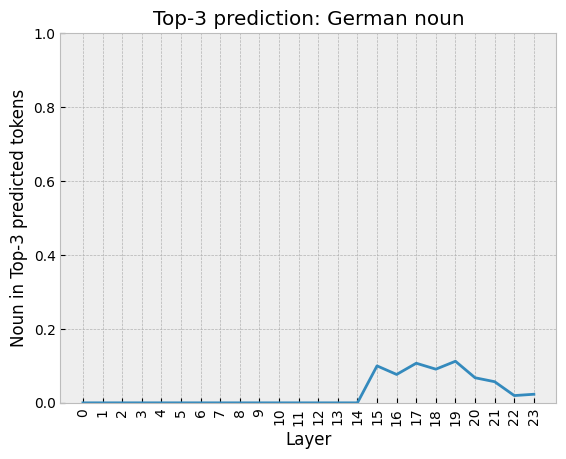

In [9]:
plot_by_layer(
    mgpt_habe_l_arrays,
    NUM_LAYERS,
    "top3_noun_ger",
    title="Top-3 prediction: German noun",
    ylabel="Noun in Top-3 predicted tokens"
)


### Verbs

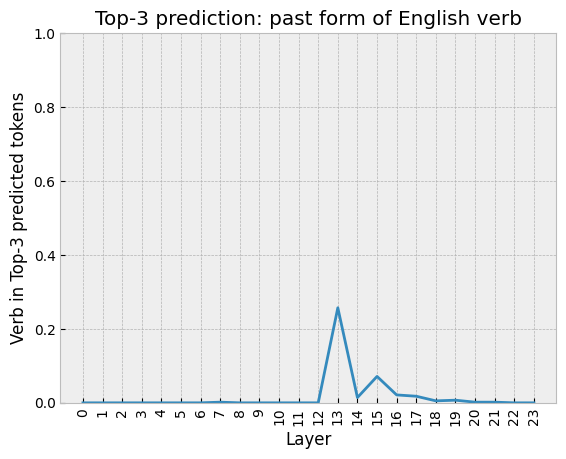

In [10]:
plot_by_layer(
    mgpt_habe_l_arrays,
    NUM_LAYERS,
    "top3_verb_eng",
    title="Top-3 prediction: past form of English verb",
    ylabel="Verb in Top-3 predicted tokens"
)


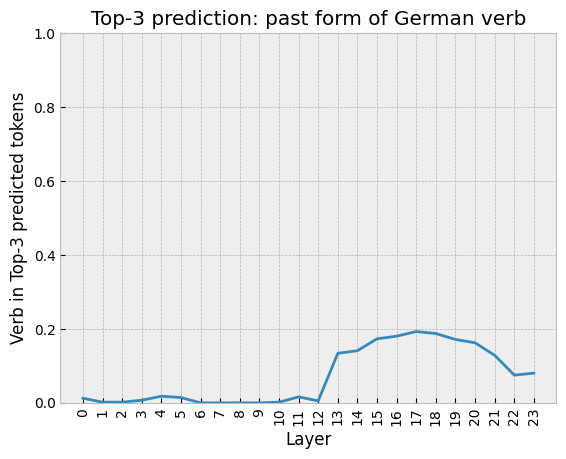

In [11]:
plot_by_layer(
    mgpt_habe_l_arrays,
    NUM_LAYERS,
    "top3_perf_ger",
    title="Top-3 prediction: past form of German verb",
    ylabel="Verb in Top-3 predicted tokens"
)

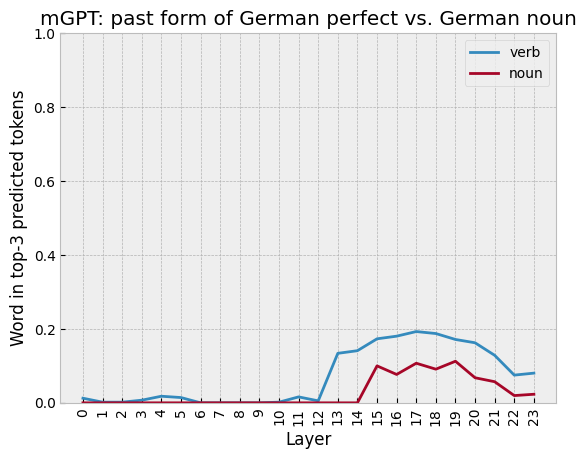

In [19]:
plt.plot(mgpt_habe_l_arrays['top3_perf_ger'].mean(axis=0), label="verb")
plt.plot(mgpt_habe_l_arrays['top3_noun_ger'].mean(axis=0), label="noun")
plt.ylim([0, 1])
plt.xticks(np.arange(24), rotation=90)
plt.title("mGPT: past form of German perfect vs. German noun")
plt.xlabel("Layer")
plt.ylabel("Word in top-3 predicted tokens")
plt.legend()

# plt.savefig('results/figures/verb_vs_noun_eng.png', dpi=300)
plt.show()

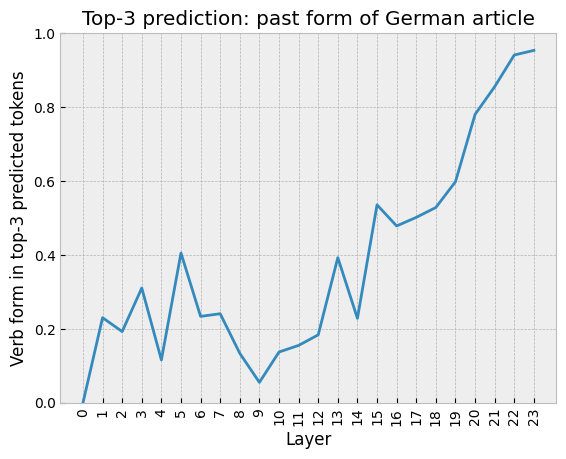

In [160]:
plt.plot(mgpt_habe_l_arrays['top3_art_ger'].mean(axis=0))
plt.ylim([0, 1])
plt.xticks(np.arange(24), rotation=90)
# plt.axvline(x=14, color='gray', linestyle=":")
# plt.axvline(x=18, color='gray', linestyle=":")
plt.title("Top-3 prediction: past form of German article")
plt.xlabel("Layer")
plt.ylabel("Verb form in top-3 predicted tokens")

plt.show()

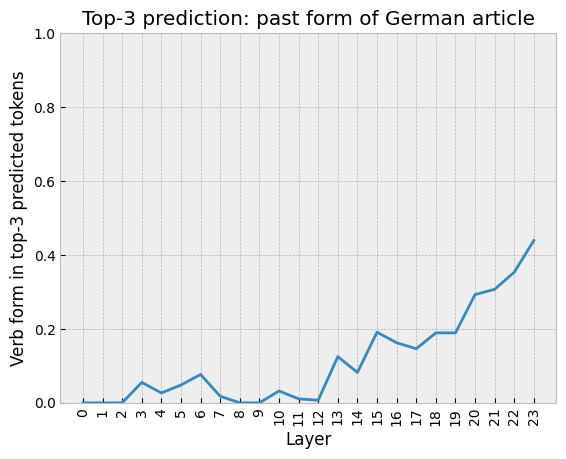

In [150]:
plt.plot(mgpt_habe_l_arrays['top1_art_ger'].mean(axis=0))
plt.ylim([0, 1])
plt.xticks(np.arange(24), rotation=90)
# plt.axvline(x=14, color='gray', linestyle=":")
# plt.axvline(x=18, color='gray', linestyle=":")
plt.title("Top-3 prediction: past form of German article")
plt.xlabel("Layer")
plt.ylabel("Verb form in top-3 predicted tokens")

plt.show()

In [152]:
for l in range(NUM_LAYERS):
    mgpt_habe_l_arrays['top1_wrongart_ger'][:, l] = dataset_mgpt_habe[f'layer_{l}_pred_0_wrongart_ger'].to_numpy(dtype=np.int64)
    mgpt_habe_l_arrays['top3_wrongart_ger'][:, l] = dataset_mgpt_habe[f'top3_{l}_wrongart_ger'].to_numpy(dtype=np.int64)

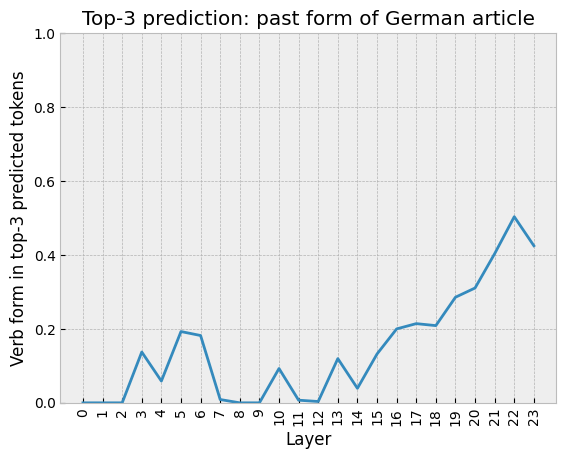

In [153]:
plt.plot(mgpt_habe_l_arrays['top1_wrongart_ger'].mean(axis=0))
plt.ylim([0, 1])
plt.xticks(np.arange(24), rotation=90)
# plt.axvline(x=14, color='gray', linestyle=":")
# plt.axvline(x=18, color='gray', linestyle=":")
plt.title("Top-3 prediction: past form of German article")
plt.xlabel("Layer")
plt.ylabel("Verb form in top-3 predicted tokens")

plt.show()

In [17]:
different_verbforms = dataset[dataset.perf_eng != dataset.past_eng]

In [35]:
past_forms = mgpt_habe_l_arrays['top3_past_eng'][different_verbforms.index].mean(axis=0)
perf_forms = mgpt_habe_l_arrays['top3_perf_eng'][different_verbforms.index].mean(axis=0)

plt.plot(past_forms, label="past simple")
plt.plot(perf_forms, label="past participle")
plt.ylim([0, 1])
plt.xticks(np.arange(24), rotation=90)
plt.title("Top-3 tokens: English verb form")
plt.xlabel("Layer")
plt.ylabel("Verb form in top-3 predicted tokens")
plt.legend()
plt.savefig("visualisations/figures/past_vs_perf_eng.png", dpi=300)
plt.show()

NameError: name 'different_verbforms' is not defined

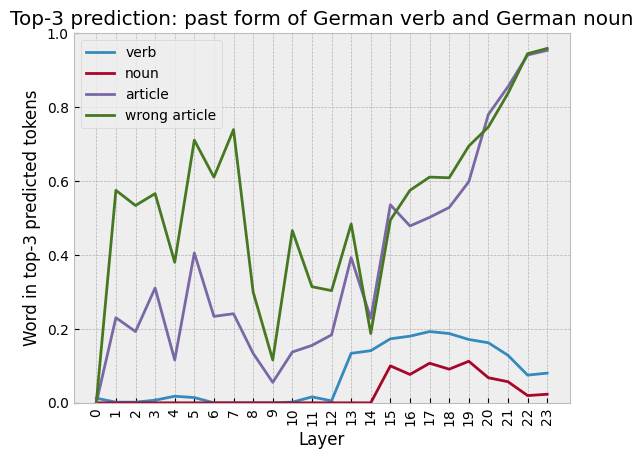

In [161]:
plt.plot(mgpt_habe_l_arrays['top3_perf_ger'].mean(axis=0), label="verb")
plt.plot(mgpt_habe_l_arrays['top3_noun_ger'].mean(axis=0), label="noun")
plt.plot(mgpt_habe_l_arrays['top3_art_ger'].mean(axis=0), label="article")
plt.plot(mgpt_habe_l_arrays['top3_wrongart_ger'].mean(axis=0), label="wrong article")
plt.ylim([0, 1])
plt.xticks(np.arange(NUM_LAYERS), rotation=90)
plt.title("Top-3 prediction: past form of German verb and German noun")
plt.xlabel("Layer")
plt.ylabel("Word in top-3 predicted tokens")
plt.legend()

plt.show()

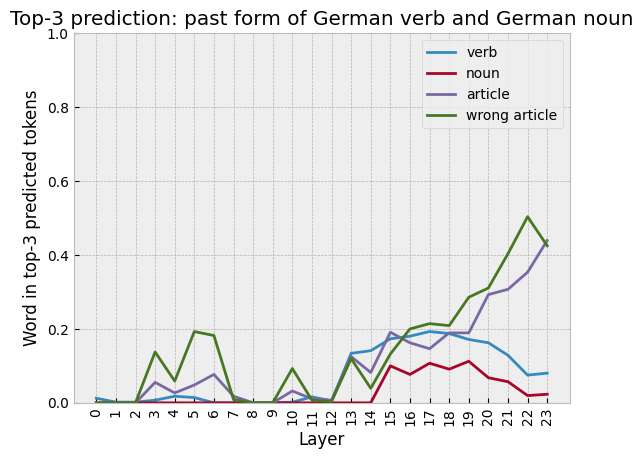

In [163]:
plt.plot(mgpt_habe_l_arrays['top3_perf_ger'].mean(axis=0), label="verb")
plt.plot(mgpt_habe_l_arrays['top3_noun_ger'].mean(axis=0), label="noun")
plt.plot(mgpt_habe_l_arrays['top1_art_ger'].mean(axis=0), label="article")
plt.plot(mgpt_habe_l_arrays['top1_wrongart_ger'].mean(axis=0), label="wrong article")
plt.ylim([0, 1])
plt.xticks(np.arange(NUM_LAYERS), rotation=90)
plt.title("Top-3 prediction: past form of German verb and German noun")
plt.xlabel("Layer")
plt.ylabel("Word in top-3 predicted tokens")
plt.legend()

plt.show()

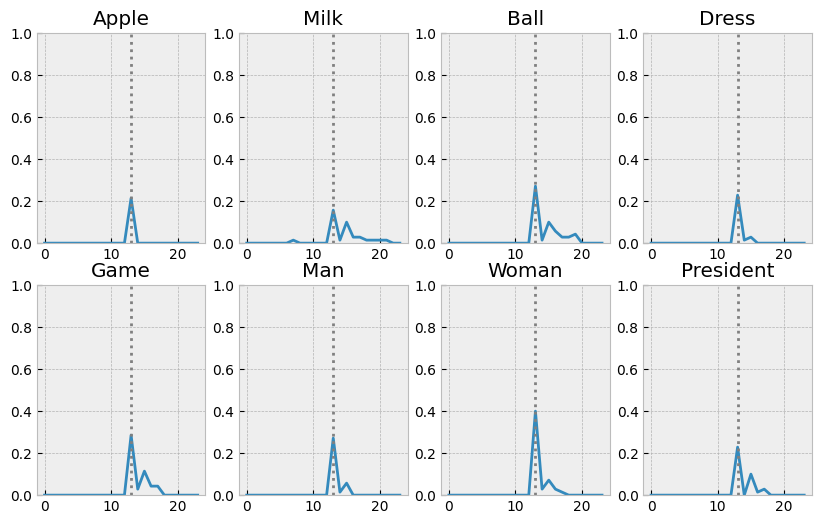

In [21]:
figure = plt.figure(figsize=(10,6))
axis = figure.subplots(2, 4)

axis[0, 0].plot(layer_arrays['top3_verb_eng'][dataset_index_apple].mean(axis=0))
axis[0, 0].set_ylim([0,1])
axis[0, 0].axvline(x=13, color='gray', linestyle=":")
axis[0, 0].set_title("Apple")

axis[0, 1].plot(layer_arrays['top3_verb_eng'][dataset_index_milk].mean(axis=0))
axis[0, 1].set_ylim([0,1])
axis[0, 1].axvline(x=13, color='gray', linestyle=":")
axis[0, 1].set_title("Milk")

axis[0, 2].plot(layer_arrays['top3_verb_eng'][dataset_index_ball].mean(axis=0))
axis[0, 2].set_ylim([0,1])
axis[0, 2].axvline(x=13, color='gray', linestyle=":")
axis[0, 2].set_title("Ball")

axis[0, 3].plot(layer_arrays['top3_verb_eng'][dataset_index_dress].mean(axis=0))
axis[0, 3].set_ylim([0,1])
axis[0, 3].axvline(x=13, color='gray', linestyle=":")
axis[0, 3].set_title("Dress")

axis[1, 0].plot(layer_arrays['top3_verb_eng'][dataset_index_game].mean(axis=0))
axis[1, 0].set_ylim([0,1])
axis[1, 0].axvline(x=13, color='gray', linestyle=":")
axis[1, 0].set_title("Game")

axis[1, 1].plot(layer_arrays['top3_verb_eng'][dataset_index_man].mean(axis=0))
axis[1, 1].set_ylim([0,1])
axis[1, 1].axvline(x=13, color='gray', linestyle=":")
axis[1, 1].set_title("Man")

axis[1, 2].plot(layer_arrays['top3_verb_eng'][dataset_index_woman].mean(axis=0))
axis[1, 2].set_ylim([0,1])
axis[1, 2].axvline(x=13, color='gray', linestyle=":")
axis[1, 2].set_title("Woman")

axis[1, 3].plot(layer_arrays['top3_verb_eng'][dataset_index_president].mean(axis=0))
axis[1, 3].set_ylim([0,1])
axis[1, 3].axvline(x=13, color='gray', linestyle=":")
axis[1, 3].set_title("President")

plt.show()

In [54]:
mgpt_habe_l_arraysfigure = plt.figure(figsize=(10,6))
axis = figure.subplots(2, 4)

axis[0, 0].plot(mgpt_habe_l_arrays['top3_perf_ger'][dataset_index_apple].mean(axis=0))
axis[0, 0].set_ylim([0,1])
axis[0, 0].axvline(x=13, color='gray', linestyle=":")
axis[0, 0].set_title("Apple")

axis[0, 1].plot(mgpt_habe_l_arrays['top3_perf_ger'][dataset_index_milk].mean(axis=0))
axis[0, 1].set_ylim([0,1])
axis[0, 1].axvline(x=13, color='gray', linestyle=":")
axis[0, 1].set_title("Milk")

axis[0, 2].plot(mgpt_habe_l_arrays['top3_perf_ger'][dataset_index_ball].mean(axis=0))
axis[0, 2].set_ylim([0,1])
axis[0, 2].axvline(x=13, color='gray', linestyle=":")
axis[0, 2].set_title("Ball")

axis[0, 3].plot(mgpt_habe_l_arrays['top3_perf_ger'][dataset_index_dress].mean(axis=0))
axis[0, 3].set_ylim([0,1])
axis[0, 3].axvline(x=13, color='gray', linestyle=":")
axis[0, 3].set_title("Dress")

axis[1, 0].plot(mgpt_habe_l_arrays['top3_perf_ger'][dataset_index_game].mean(axis=0))
axis[1, 0].set_ylim([0,1])
axis[1, 0].axvline(x=13, color='gray', linestyle=":")
axis[1, 0].set_title("Game")

axis[1, 1].plot(mgpt_habe_l_arrays['top3_perf_ger'][dataset_index_man].mean(axis=0))
axis[1, 1].set_ylim([0,1])
axis[1, 1].axvline(x=13, color='gray', linestyle=":")
axis[1, 1].set_title("Man")

axis[1, 2].plot(mgpt_habe_l_arrays['top3_perf_ger'][dataset_index_woman].mean(axis=0))
axis[1, 2].set_ylim([0,1])
axis[1, 2].axvline(x=13, color='gray', linestyle=":")
axis[1, 2].set_title("Woman")

axis[1, 3].plot(mgpt_habe_l_arrays['top3_perf_ger'][dataset_index_president].mean(axis=0))
axis[1, 3].set_ylim([0,1])
axis[1, 3].axvline(x=13, color='gray', linestyle=":")
axis[1, 3].set_title("President")

plt.show()

NameError: name 'dataset_index_apple' is not defined

<Figure size 1000x600 with 0 Axes>

TypeError: 'function' object is not subscriptable

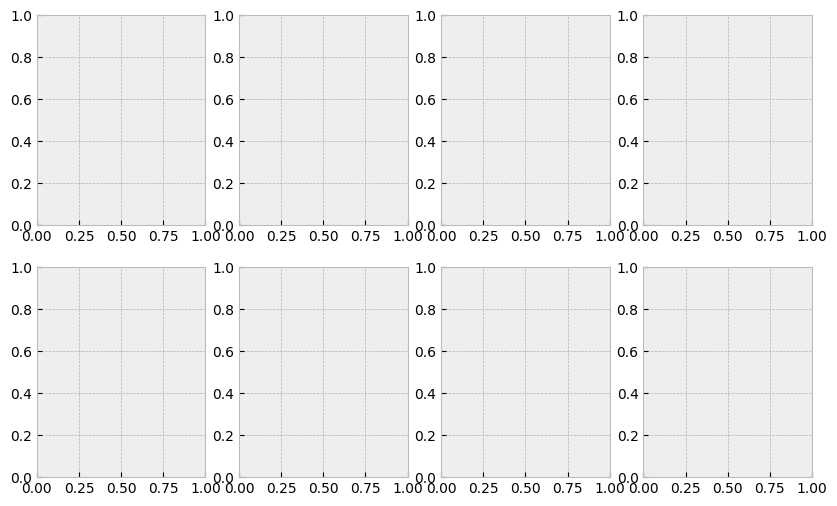

In [53]:
figure = plt.figure(figsize=(10,6))
axis = figure.subplots(2, 4)

axis[0, 0].plot(layer_arrays['top3_art_ger'][dataset_index_apple].mean(axis=0))
axis[0, 0].set_ylim([0,1])
axis[0, 0].set_title("Apple")

axis[0, 1].plot(layer_arrays['top3_art_ger'][dataset_index_milk].mean(axis=0))
axis[0, 1].set_ylim([0,1])
axis[0, 1].axvline(x=13, color='gray', linestyle=":")
axis[0, 1].set_title("Milk")

axis[0, 2].plot(layer_arrays['top3_art_ger'][dataset_index_ball].mean(axis=0))
axis[0, 2].set_ylim([0,1])
axis[0, 2].set_title("Ball")

axis[0, 3].plot(layer_arrays['top3_art_ger'][dataset_index_dress].mean(axis=0))
axis[0, 3].set_ylim([0,1])
axis[0, 3].set_title("Dress")

axis[1, 0].plot(layer_arrays['top3_art_ger'][dataset_index_game].mean(axis=0))
axis[1, 0].set_ylim([0,1])
axis[1, 0].set_title("Game")

axis[1, 1].plot(layer_arrays['top3_art_ger'][dataset_index_man].mean(axis=0))
axis[1, 1].set_ylim([0,1])
axis[1, 1].set_title("Man")

axis[1, 2].plot(layer_arrays['top3_art_ger'][dataset_index_woman].mean(axis=0))
axis[1, 2].set_ylim([0,1])
axis[1, 2].set_title("Woman")

axis[1, 3].plot(layer_arrays['top3_art_ger'][dataset_index_president].mean(axis=0))
axis[1, 3].set_ylim([0,1])
axis[1, 3].set_title("President")

plt.show()

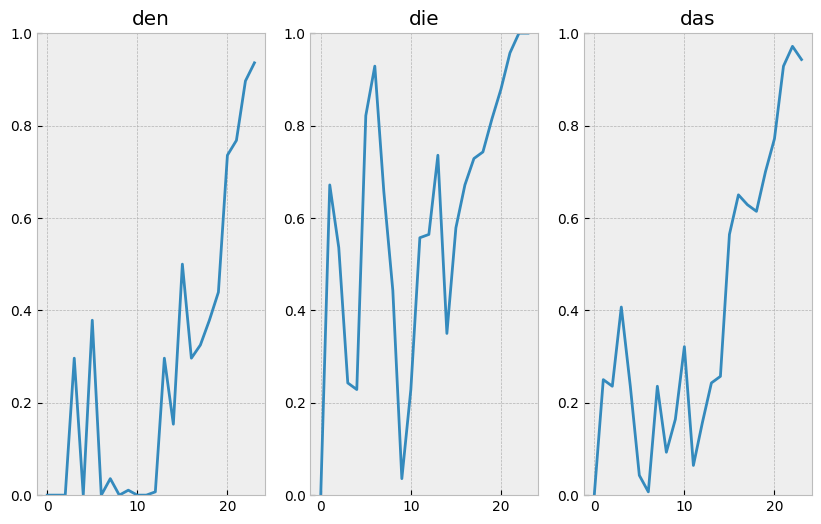

In [99]:
figure = plt.figure(figsize=(10,6))
axis = figure.subplots(1, 3)

axis[0].plot(layer_arrays['top3_art_ger'][dataset_index_den].mean(axis=0))
axis[0].set_ylim([0,1])
axis[0].set_title("den")

axis[1].plot(layer_arrays['top3_art_ger'][dataset_index_die].mean(axis=0))
axis[1].set_ylim([0,1])
axis[1].set_title("die")

axis[2].plot(layer_arrays['top3_art_ger'][dataset_index_das].mean(axis=0))
axis[2].set_ylim([0,1])
axis[2].set_title("das")

plt.show()

In [43]:
plt.plot(layer_arrays['top3_verb_ger'].mean(axis=0))
plt.ylim([0, 1])
plt.xticks(np.arange(24), rotation=90)
# plt.axvline(x=14, color='gray', linestyle=":")
# plt.axvline(x=18, color='gray', linestyle=":")
plt.title("Top-3 prediction: past form of English verb")
plt.xlabel("Layer")
plt.ylabel("Verb form in top-3 predicted tokens")

plt.savefig('visualisations/figures/verb_eng_top3.png', dpi=300)
plt.show()

defaultdict(<function __main__.<lambda>()>,
            {'top3_perf_eng': array([[0., 0., 0., ..., 0., 0., 0.],
                    [0., 0., 0., ..., 0., 0., 0.],
                    [0., 0., 0., ..., 0., 0., 0.],
                    ...,
                    [0., 0., 0., ..., 0., 0., 0.],
                    [0., 0., 0., ..., 0., 0., 0.],
                    [0., 0., 0., ..., 0., 0., 0.]]),
             'top3_past_eng': array([[0., 0., 0., ..., 0., 0., 0.],
                    [0., 0., 0., ..., 0., 0., 0.],
                    [0., 0., 0., ..., 0., 0., 0.],
                    ...,
                    [0., 0., 0., ..., 0., 0., 0.],
                    [0., 0., 0., ..., 0., 0., 0.],
                    [0., 0., 0., ..., 0., 0., 0.]]),
             'top3_perf_ger': array([[0., 0., 0., ..., 0., 0., 0.],
                    [0., 0., 0., ..., 0., 0., 0.],
                    [0., 0., 0., ..., 0., 0., 0.],
                    ...,
                    [0., 0., 0., ..., 0., 0., 0.],
          

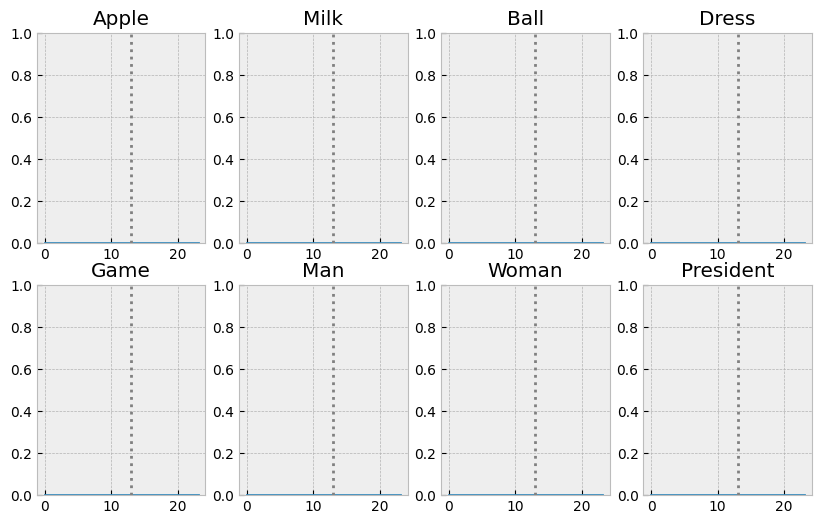

In [42]:
figure = plt.figure(figsize=(10,6))
axis = figure.subplots(2, 4)

axis[0, 0].plot(layer_arrays['top3_verb_ger'][dataset_index_apple].mean(axis=0))
axis[0, 0].set_ylim([0,1])
axis[0, 0].axvline(x=13, color='gray', linestyle=":")
axis[0, 0].set_title("Apple")

axis[0, 1].plot(layer_arrays['top3_verb_ger'][dataset_index_milk].mean(axis=0))
axis[0, 1].set_ylim([0,1])
axis[0, 1].axvline(x=13, color='gray', linestyle=":")
axis[0, 1].set_title("Milk")

axis[0, 2].plot(layer_arrays['top3_verb_ger'][dataset_index_ball].mean(axis=0))
axis[0, 2].set_ylim([0,1])
axis[0, 2].axvline(x=13, color='gray', linestyle=":")
axis[0, 2].set_title("Ball")

axis[0, 3].plot(layer_arrays['top3_verb_ger'][dataset_index_dress].mean(axis=0))
axis[0, 3].set_ylim([0,1])
axis[0, 3].axvline(x=13, color='gray', linestyle=":")
axis[0, 3].set_title("Dress")

axis[1, 0].plot(layer_arrays['top3_verb_ger'][dataset_index_game].mean(axis=0))
axis[1, 0].set_ylim([0,1])
axis[1, 0].axvline(x=13, color='gray', linestyle=":")
axis[1, 0].set_title("Game")

axis[1, 1].plot(layer_arrays['top3_verb_ger'][dataset_index_man].mean(axis=0))
axis[1, 1].set_ylim([0,1])
axis[1, 1].axvline(x=13, color='gray', linestyle=":")
axis[1, 1].set_title("Man")

axis[1, 2].plot(layer_arrays['top3_verb_ger'][dataset_index_woman].mean(axis=0))
axis[1, 2].set_ylim([0,1])
axis[1, 2].axvline(x=13, color='gray', linestyle=":")
axis[1, 2].set_title("Woman")

axis[1, 3].plot(layer_arrays['top3_verb_ger'][dataset_index_president].mean(axis=0))
axis[1, 3].set_ylim([0,1])
axis[1, 3].axvline(x=13, color='gray', linestyle=":")
axis[1, 3].set_title("President")

plt.savefig('visualisations/figures/verb_ger_top3_by_obj.png', dpi=300)
plt.show()

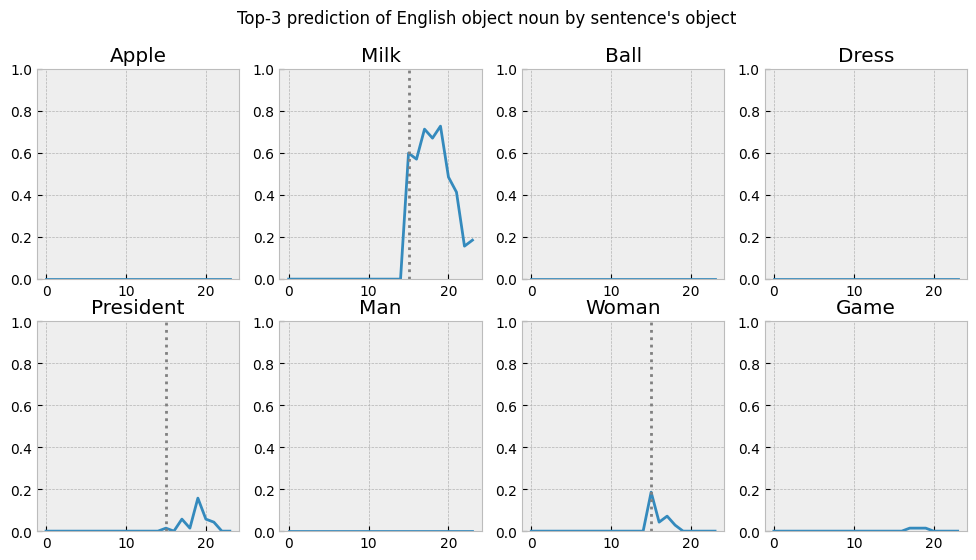

In [29]:
figure = plt.figure(figsize=(12,6))
figure.suptitle("Top-3 prediction of English object noun by sentence's object")

axis = figure.subplots(2, 4)

axis[0, 0].plot(layer_arrays['top3_noun_ger'][dataset_index_apple].mean(axis=0))
axis[0, 0].set_ylim([0,1])
axis[0, 0].set_title("Apple")

axis[0, 1].plot(layer_arrays['top3_noun_ger'][dataset_index_milk].mean(axis=0))
axis[0, 1].set_ylim([0,1])
axis[0, 1].axvline(x=15, color='gray', linestyle=":")
axis[0, 1].set_title("Milk")

axis[0, 2].plot(layer_arrays['top3_noun_ger'][dataset_index_ball].mean(axis=0))
axis[0, 2].set_ylim([0,1])
axis[0, 2].set_title("Ball")

axis[0, 3].plot(layer_arrays['top3_noun_ger'][dataset_index_dress].mean(axis=0))
axis[0, 3].set_ylim([0,1])
axis[0, 3].set_title("Dress")

axis[1, 0].plot(layer_arrays['top3_noun_ger'][dataset_index_president].mean(axis=0))
axis[1, 0].set_ylim([0,1])
axis[1, 0].axvline(x=15, color='gray', linestyle=":")
axis[1, 0].set_title("President")

axis[1, 1].plot(layer_arrays['top3_noun_ger'][dataset_index_man].mean(axis=0))
axis[1, 1].set_ylim([0,1])
axis[1, 1].set_title("Man")

axis[1, 2].plot(layer_arrays['top3_noun_ger'][dataset_index_woman].mean(axis=0))
axis[1, 2].set_ylim([0,1])
axis[1, 2].axvline(x=15, color='gray', linestyle=":")
axis[1, 2].set_title("Woman")

axis[1, 3].plot(layer_arrays['top3_noun_ger'][dataset_index_game].mean(axis=0))
axis[1, 3].set_ylim([0,1])
axis[1, 3].set_title("Game")

plt.savefig("visualisations/figures/noun_ger_top3_by_obj.png", dpi=300)
plt.show()

In [45]:
dataset.columns[100:]

Index(['top3_18_perf_ger', 'top3_19_perf_ger', 'top3_20_perf_ger',
       'top3_21_perf_ger', 'top3_22_perf_ger', 'top3_23_perf_ger',
       'top3_0_perf_eng', 'top3_1_perf_eng', 'top3_2_perf_eng',
       'top3_3_perf_eng',
       ...
       'top3_15_noun_eng', 'top3_16_noun_eng', 'top3_17_noun_eng',
       'top3_18_noun_eng', 'top3_19_noun_eng', 'top3_20_noun_eng',
       'top3_21_noun_eng', 'top3_22_noun_eng', 'top3_23_noun_eng',
       'coll_freq_per_million'],
      dtype='object', length=103)

In [100]:
SENTENCE_CSV_PATH = "data/toy_dataset_mgpt_fre.csv"
NUM_LAYERS = 24
SAMPLE_SIZE = 70

In [104]:
dataset = pd.read_csv(SENTENCE_CSV_PATH, index_col=0)

In [121]:
print(dataset.layer_13_pred_0)
print(dataset.layer_13_pred_1)
print(dataset.layer_13_pred_2)

0       Ġmaison
1    Ġmeilleure
2        Ġpetit
3         homme
4        Ġlivre
Name: layer_13_pred_0, dtype: object
0     ĠMaison
1      Ġbonne
2    Ġtableau
3       Homme
4      ĠLivre
Name: layer_13_pred_1, dtype: object
0        Ġred
1    Ġplupart
2       Ġvrai
3      enfant
4       Ġvrai
Name: layer_13_pred_2, dtype: object


In [124]:
print(dataset.layer_14_pred_0)
print(dataset.layer_14_pred_1)
print(dataset.layer_14_pred_2)

0     Ġmaison
1    Ġplupart
2    Ġtableau
3       homme
4      Ġlivre
Name: layer_14_pred_0, dtype: object
0       ĠMaison
1    Ġmeilleure
2        Ġlivre
3        enfant
4        ĠLivre
Name: layer_14_pred_1, dtype: object
0       Ġsalle
1       Ġbonne
2    Ġmeilleur
3        Homme
4     Ġtableau
Name: layer_14_pred_2, dtype: object


In [125]:
print(dataset.layer_15_pred_0)
print(dataset.layer_15_pred_1)
print(dataset.layer_15_pred_2)

0        Ġmaison
1    Ġnourriture
2         Ġlivre
3          homme
4         Ġlivre
Name: layer_15_pred_0, dtype: object
0     ĠMaison
1    Ġplupart
2      Ġpetit
3       Homme
4      ĠLivre
Name: layer_15_pred_1, dtype: object
0      Ġsalle
1     ĠpÃªche
2    Ġtableau
3      enfant
4    Ġtableau
Name: layer_15_pred_2, dtype: object


# Empty F-sentence

## GPT-J

In [55]:
SENTENCE_CSV_PATH = "data/dataset_gptj_empty.csv"
NUM_LAYERS = 28

# loading the sentence dataset
dataset_gptj_empty = pd.read_csv(SENTENCE_CSV_PATH, index_col=0)
dataset_gptj_empty['coll_freq_per_million'] = (dataset_gptj_empty['coll_freq'] / dataset_gptj_empty['obj_freq']) * 10**6
dataset_gptj_empty = dataset_gptj_empty.groupby('noun_ger').sample(n=SAMPLE_SIZE, random_state=RANDOM_STATE) # equalizing the dataset
dataset_gptj_empty.reset_index(drop=True, inplace=True)

gptj_empty_d_indices = dataset_indices(dataset_gptj_empty)
gptj_empty_l_arrays = layer_arrays(dataset_gptj_empty, NUM_LAYERS)


### Noun

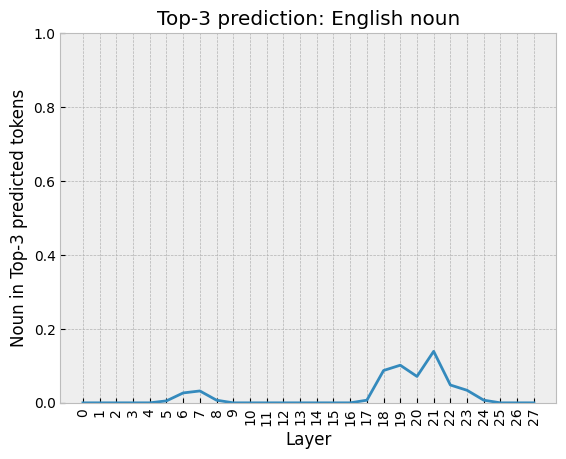

In [58]:
plot_by_layer(
    gptj_empty_l_arrays,
    NUM_LAYERS,
    "top3_noun_eng",
    title="Top-3 prediction: English noun",
    ylabel="Noun in Top-3 predicted tokens"
)


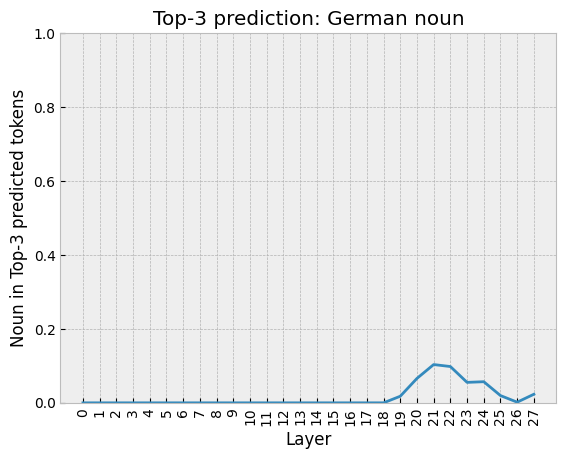

In [57]:
plot_by_layer(
    gptj_empty_l_arrays,
    NUM_LAYERS,
    "top3_noun_ger",
    title="Top-3 prediction: German noun",
    ylabel="Noun in Top-3 predicted tokens"
)


### Verb

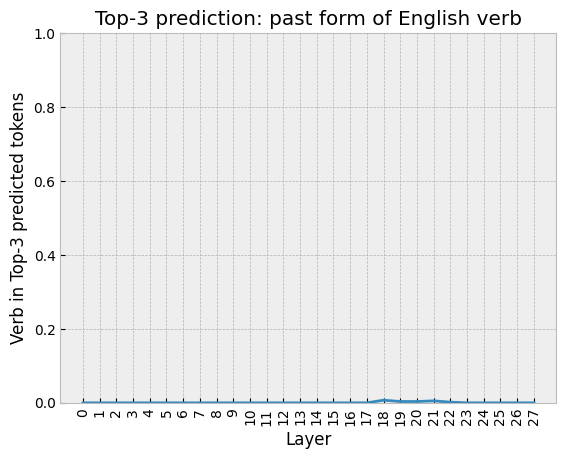

In [59]:
plot_by_layer(
    gptj_empty_l_arrays,
    NUM_LAYERS,
    "top3_verb_eng",
    title="Top-3 prediction: past form of English verb",
    ylabel="Verb in Top-3 predicted tokens"
)


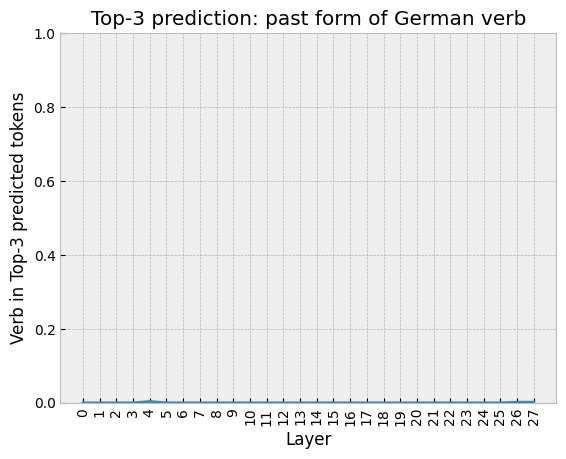

In [61]:
plot_by_layer(
    gptj_empty_l_arrays,
    NUM_LAYERS,
    "top3_perf_ger",
    title="Top-3 prediction: past form of German verb",
    ylabel="Verb in Top-3 predicted tokens"
)


## mGPT

In [63]:
SENTENCE_CSV_PATH = "data/dataset_mgpt_empty.csv"
NUM_LAYERS = 24

# loading the sentence dataset
dataset_mgpt_empty = pd.read_csv(SENTENCE_CSV_PATH, index_col=0)
dataset_mgpt_empty['coll_freq_per_million'] = (dataset_mgpt_empty['coll_freq'] / dataset_mgpt_empty['obj_freq']) * 10**6
dataset_mgpt_empty = dataset_mgpt_empty.groupby('noun_ger').sample(n=SAMPLE_SIZE, random_state=RANDOM_STATE) # equalizing the dataset
dataset_mgpt_empty.reset_index(drop=True, inplace=True)

mgpt_empty_d_indices = dataset_indices(dataset_mgpt_empty)
mgpt_empty_l_arrays = layer_arrays(dataset_mgpt_empty, NUM_LAYERS)


### Noun

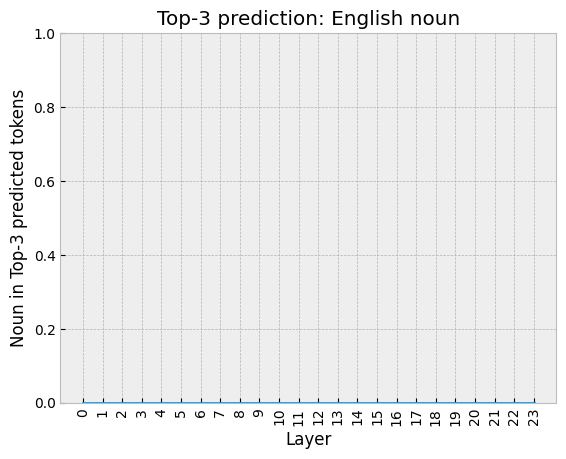

In [64]:
plot_by_layer(
    mgpt_empty_l_arrays,
    NUM_LAYERS,
    "top3_noun_eng",
    title="Top-3 prediction: English noun",
    ylabel="Noun in Top-3 predicted tokens"
)


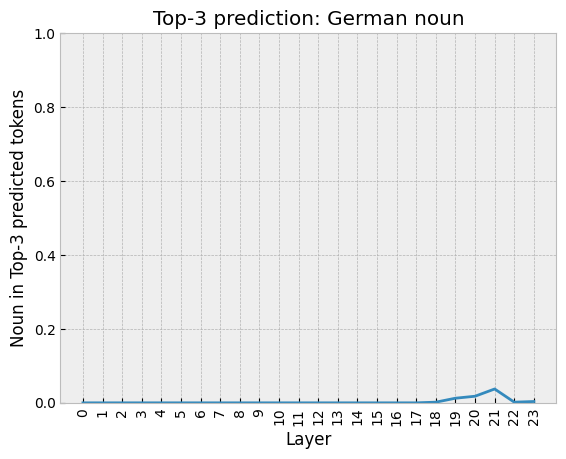

In [65]:
plot_by_layer(
    mgpt_empty_l_arrays,
    NUM_LAYERS,
    "top3_noun_ger",
    title="Top-3 prediction: German noun",
    ylabel="Noun in Top-3 predicted tokens"
)


### Verb

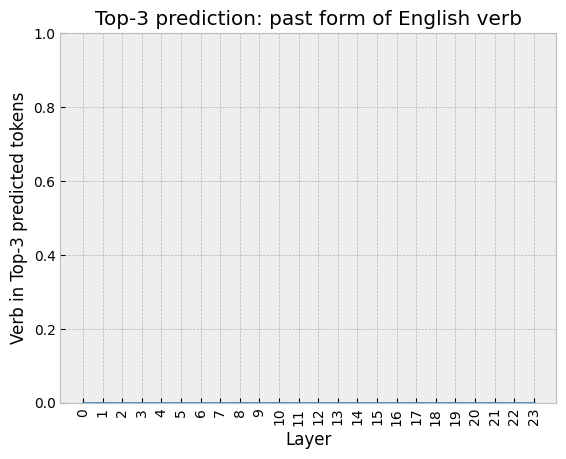

In [66]:
plot_by_layer(
    mgpt_empty_l_arrays,
    NUM_LAYERS,
    "top3_verb_eng",
    title="Top-3 prediction: past form of English verb",
    ylabel="Verb in Top-3 predicted tokens"
)


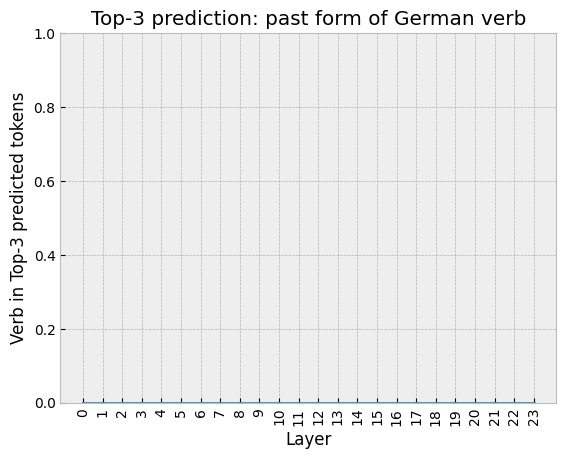

In [67]:
plot_by_layer(
    mgpt_empty_l_arrays,
    NUM_LAYERS,
    "top3_perf_ger",
    title="Top-3 prediction: past form of German verb",
    ylabel="Verb in Top-3 predicted tokens"
)


In [ ]:
plt.plot(mgpt_habe_l_arrays['top3_perf_ger'].mean(axis=0), label="verb")
plt.plot(mgpt_habe_l_arrays['top3_noun_ger'].mean(axis=0), label="noun")
plt.plot(mgpt_habe_l_arrays['top3_art_ger'].mean(axis=0), label="article")
plt.plot(mgpt_habe_l_arrays['top3_wrongart_ger'].mean(axis=0), label="wrong article")
plt.ylim([0, 1])
plt.xticks(np.arange(NUM_LAYERS), rotation=90)
plt.title("Top-3 prediction: past form of German verb and German noun")
plt.xlabel("Layer")
plt.ylabel("Word in top-3 predicted tokens")
plt.legend()

plt.show()

# After Noun

## GPT-J

In [75]:
SENTENCE_CSV_PATH = "data/dataset_gptj_noun.csv"
NUM_LAYERS = 28

# loading the sentence dataset
dataset_gptj_noun = pd.read_csv(SENTENCE_CSV_PATH, index_col=0)
dataset_gptj_noun['coll_freq_per_million'] = (dataset_gptj_noun['coll_freq'] / dataset_gptj_noun['obj_freq']) * 10**6
dataset_gptj_noun = dataset_gptj_noun.groupby('noun_ger').sample(n=SAMPLE_SIZE, random_state=RANDOM_STATE) # equalizing the dataset
dataset_gptj_noun.reset_index(drop=True, inplace=True)

gptj_noun_d_indices = dataset_indices(dataset_gptj_noun)
gptj_noun_l_arrays = layer_arrays(dataset_gptj_noun, NUM_LAYERS)

### Noun

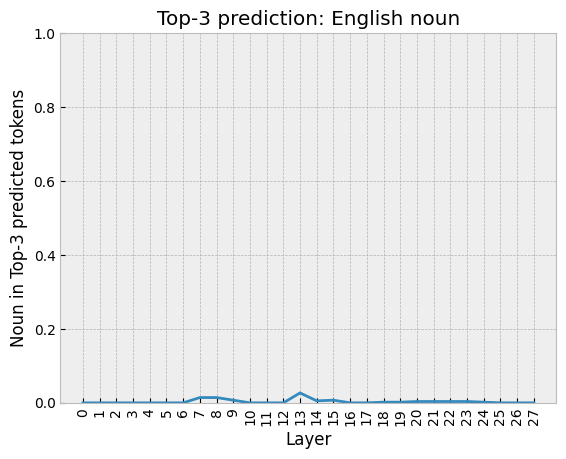

In [76]:
plot_by_layer(
    gptj_noun_l_arrays,
    NUM_LAYERS,
    "top3_noun_eng",
    title="Top-3 prediction: English noun",
    ylabel="Noun in Top-3 predicted tokens"
)


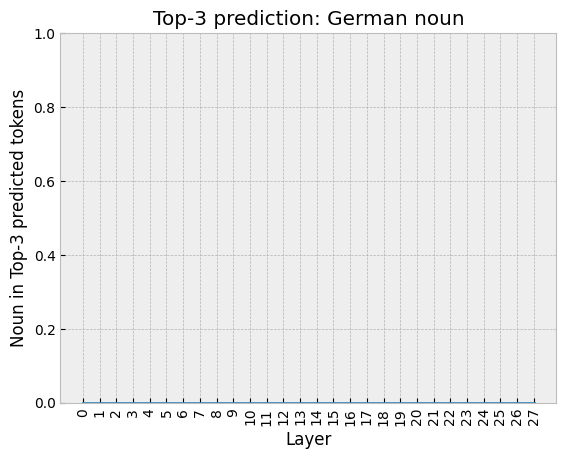

In [77]:
plot_by_layer(
    gptj_noun_l_arrays,
    NUM_LAYERS,
    "top3_noun_ger",
    title="Top-3 prediction: German noun",
    ylabel="Noun in Top-3 predicted tokens"
)


### Verb

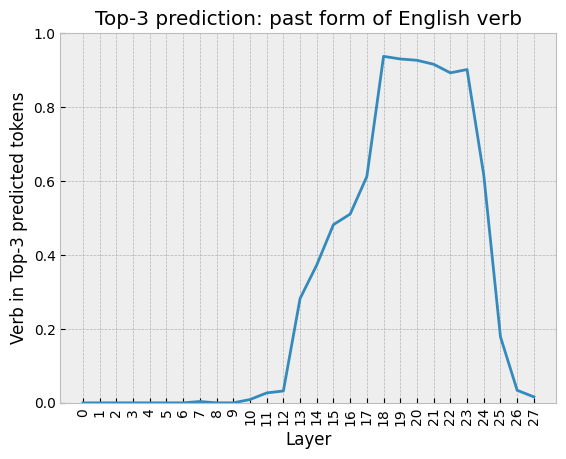

In [78]:
plot_by_layer(
    gptj_noun_l_arrays,
    NUM_LAYERS,
    "top3_verb_eng",
    title="Top-3 prediction: past form of English verb",
    ylabel="Verb in Top-3 predicted tokens"
)


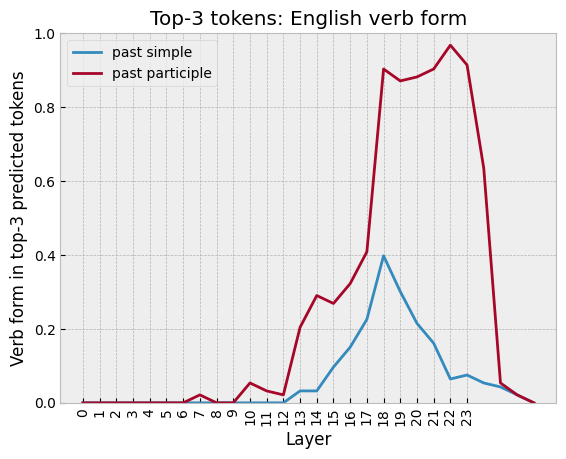

In [89]:
# Past vs. Perf
different_verbforms_gptj_noun = dataset_gptj_noun[dataset_gptj_noun.perf_eng != dataset_gptj_noun.past_eng]
different_verbforms_gptj_noun.tail()

past_forms = gptj_noun_l_arrays['top3_past_eng'][different_verbforms_gptj_noun.index].mean(axis=0)
perf_forms = gptj_noun_l_arrays['top3_perf_eng'][different_verbforms_gptj_noun.index].mean(axis=0)

plt.plot(past_forms, label="past simple")
plt.plot(perf_forms, label="past participle")
plt.ylim([0, 1])
plt.xticks(np.arange(27), rotation=90)
plt.title("Top-3 tokens: English verb form")
plt.xlabel("Layer")
plt.ylabel("Verb form in top-3 predicted tokens")
plt.legend()
# plt.savefig("visualisations/figures/past_vs_perf_eng.png", dpi=300)
plt.show()

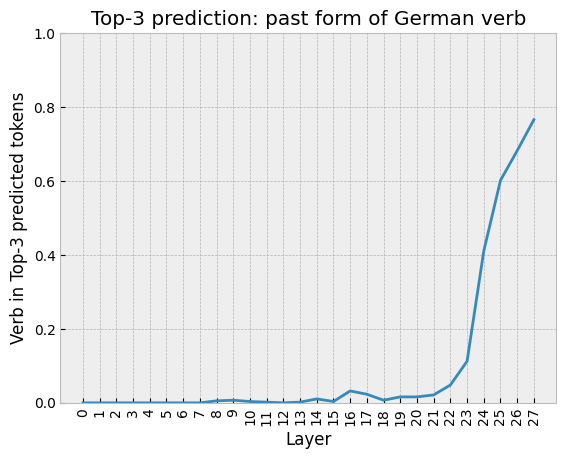

In [79]:
plot_by_layer(
    gptj_noun_l_arrays,
    NUM_LAYERS,
    "top3_perf_ger",
    title="Top-3 prediction: past form of German verb",
    ylabel="Verb in Top-3 predicted tokens"
)


## mGPT

In [80]:
SENTENCE_CSV_PATH = "data/dataset_mgpt_noun.csv"
NUM_LAYERS = 24

# loading the sentence dataset
dataset_mgpt_noun = pd.read_csv(SENTENCE_CSV_PATH, index_col=0)
dataset_mgpt_noun['coll_freq_per_million'] = (dataset_mgpt_noun['coll_freq'] / dataset_mgpt_noun['obj_freq']) * 10**6
dataset_mgpt_noun = dataset_mgpt_noun.groupby('noun_ger').sample(n=SAMPLE_SIZE, random_state=RANDOM_STATE) # equalizing the dataset
dataset_mgpt_noun.reset_index(drop=True, inplace=True)

mgpt_noun_d_indices = dataset_indices(dataset_mgpt_noun)
mgpt_noun_l_arrays = layer_arrays(dataset_mgpt_noun, NUM_LAYERS)


### Noun

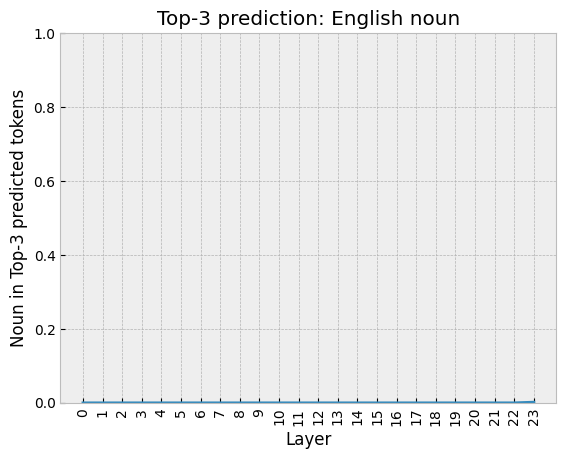

In [81]:
plot_by_layer(
    mgpt_noun_l_arrays,
    NUM_LAYERS,
    "top3_noun_eng",
    title="Top-3 prediction: English noun",
    ylabel="Noun in Top-3 predicted tokens"
)


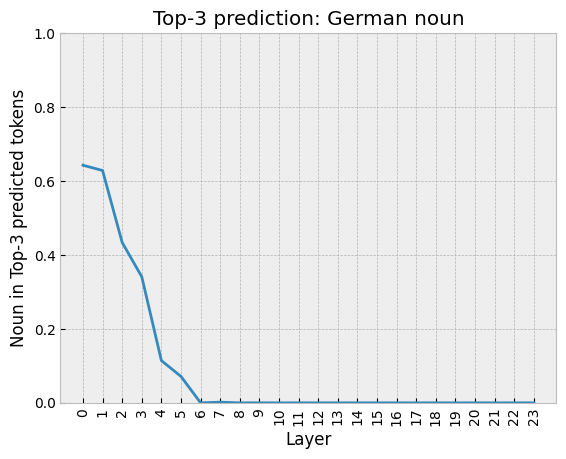

In [82]:
plot_by_layer(
    mgpt_noun_l_arrays,
    NUM_LAYERS,
    "top3_noun_ger",
    title="Top-3 prediction: German noun",
    ylabel="Noun in Top-3 predicted tokens"
)


### Verb

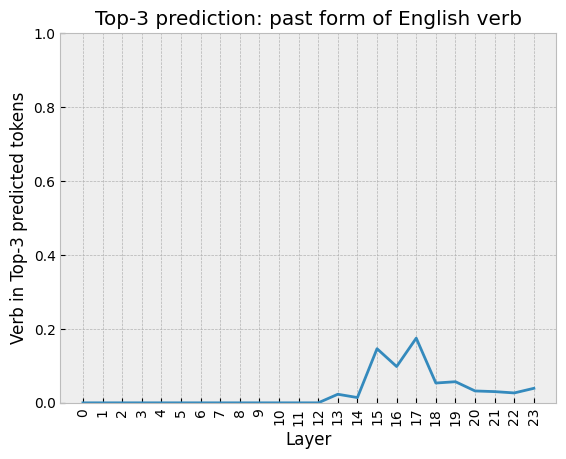

In [91]:
plot_by_layer(
    mgpt_noun_l_arrays,
    NUM_LAYERS,
    "top3_verb_eng",
    title="Top-3 prediction: past form of English verb",
    ylabel="Verb in Top-3 predicted tokens"
)


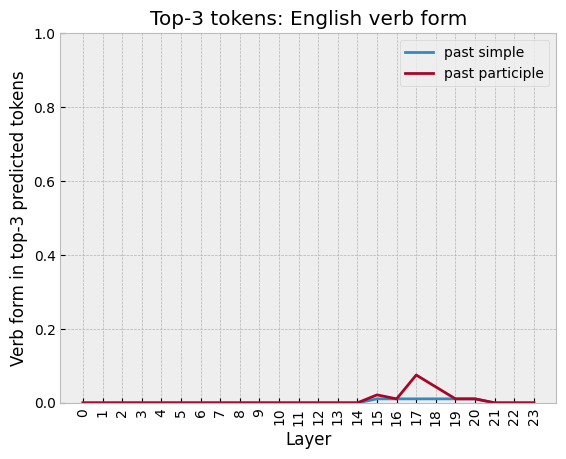

In [90]:
# Past vs. Perf
different_verbforms_mgpt_noun = dataset_mgpt_noun[dataset_mgpt_noun.perf_eng != dataset_mgpt_noun.past_eng]
different_verbforms_mgpt_noun.tail()

past_forms = mgpt_noun_l_arrays['top3_past_eng'][different_verbforms_mgpt_noun.index].mean(axis=0)
perf_forms = mgpt_noun_l_arrays['top3_perf_eng'][different_verbforms_mgpt_noun.index].mean(axis=0)

plt.plot(past_forms, label="past simple")
plt.plot(perf_forms, label="past participle")
plt.ylim([0, 1])
plt.xticks(np.arange(24), rotation=90)
plt.title("Top-3 tokens: English verb form")
plt.xlabel("Layer")
plt.ylabel("Verb form in top-3 predicted tokens")
plt.legend()
# plt.savefig("visualisations/figures/past_vs_perf_eng.png", dpi=300)
plt.show()

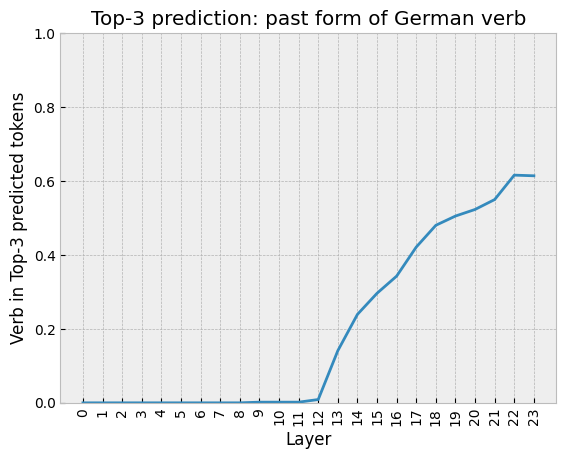

In [85]:
plot_by_layer(
    mgpt_noun_l_arrays,
    NUM_LAYERS,
    "top3_perf_ger",
    title="Top-3 prediction: past form of German verb",
    ylabel="Verb in Top-3 predicted tokens"
)
